# Mumbai Indians (2024–2026): Batting Phase-Split Analysis

This notebook examines Mumbai Indians' batting output across the 2024–2026 IPL seasons, using the same **ball-by-ball delivery data** and **match-phase framework** (powerplay: overs 1–6, middle: overs 7–15, death: overs 16–20) as the companion Bowling Analysis notebook, so results from the two are directly comparable phase-for-phase and season-for-season.

The analysis proceeds from raw data to six specific, numbers-grounded findings:

1. MI's batting shows the same **recovery-then-relapse arc** found in the bowling analysis — a 2025 death-overs peak, followed by a 2026 fall back below even 2024.
2. **Suryakumar Yadav is a middle-overs enforcer, not a death-overs finisher** — his 2026 struggles trace to an elevated powerplay dismissal rate cutting innings short before his strongest phase could begin, not to any weakness at the death, where he was consistently excellent whenever he actually got there.
3. **Ryan Rickelton emerged as MI's standout batter** in both the powerplay and middle overs in 2026, a genuine year-over-year leap rather than a small-sample blip.
4. **Will Jacks' powerplay strike rate was his best settled phase** across both his MI seasons — direct evidence for batting him at the top of the order.
5. A **three-way finisher discrepancy**: Tilak Varma's death-overs strike rate rose every season while Hardik Pandya's fell, with the 2026 gap reaching 121 points.
6. **Naman Dhir's own death-overs role was cut** in 2026 despite a productive, large-sample 2025 in that exact role — the batting mirror of the bowling notebook's Ashwani Kumar finding.
7. **Hardik Pandya's decline traces to his average, not his strike rate** — comparing his Gujarat Titans years (2022-23) against his Mumbai Indians years (2024-26) shows his tempo has held up; his ability to survive at the crease has not.
8. **Will Jacks' bowling economy against left-handed batters** is a real, two-season pattern — the deciding factor in the Rutherford-vs-Jacks overseas-slot tradeoff.

All `.to_csv()` exports used to build the accompanying dashboard are consolidated in the final section, after every finding in this notebook.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

# Okabe-Ito palette — the standard, peer-reviewed colorblind-safe palette,
# distinguishable under deuteranopia, protanopia, and tritanopia
GRAY = "#999999"      # neutral/context
ACCENT = "#D55E00"    # vermillion — the "problem/highlight" color
BLUE = "#0072B2"      # blue — the safest high-contrast pairing with vermillion
GREEN = "#009E73"     # bluish-green — for any chart needing a 3rd distinct hue 

## 2. Load ball-by-ball and match data

Two source files: per-delivery ball-by-ball data, and per-match metadata (teams, dates, venue, result). The match metadata needs a `season` column derived from the match date before it can be filtered.

In [2]:
ball_data = pd.read_csv("../data/Ball_By_Ball_Match_Data.csv")
ball_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295732 entries, 0 to 295731
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   ID                295732 non-null  int64 
 1   Innings           295732 non-null  int64 
 2   Overs             295732 non-null  int64 
 3   BallNumber        295732 non-null  int64 
 4   Batter            295732 non-null  object
 5   Bowler            295732 non-null  object
 6   NonStriker        295732 non-null  object
 7   ExtraType         16227 non-null   object
 8   BatsmanRun        295732 non-null  int64 
 9   ExtrasRun         295732 non-null  int64 
 10  TotalRun          295732 non-null  int64 
 11  IsWicketDelivery  295732 non-null  int64 
 12  PlayerOut         14705 non-null   object
 13  Kind              14705 non-null   object
 14  FieldersInvolved  10721 non-null   object
 15  BattingTeam       295732 non-null  object
dtypes: int64(8), object(8)
memory usage: 3

In [3]:
match_data = pd.read_csv("../data/Match_Info.csv")
match_data.head(10)

,match_number,team1,team2,match_date,toss_winner,toss_decision,result,eliminator,winner,player_of_match,venue,city,team1_players,team2_players
0,501208,Deccan Chargers,Royal Challengers Bangalore,2011-04-14,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
1,1216505,Royal Challengers Bangalore,Delhi Capitals,2020-11-02,Delhi Capitals,field,Win,NaN,Delhi Capitals,A Nortje,Sheikh Zayed Stadium,Abu Dhabi,"JR Philippe, D Padikkal, V Kohli, AB de Villie...","PP Shaw, S Dhawan, AM Rahane, SS Iyer, RR Pant..."
2,1359481,Delhi Capitals,Gujarat Titans,2023-04-04,Gujarat Titans,field,Win,NaN,Gujarat Titans,B Sai Sudharsan,"Arun Jaitley Stadium, Delhi",Delhi,"KK Ahmed, DA Warner, PP Shaw, MR Marsh, SN Kha...","J Little, WP Saha, Shubman Gill, B Sai Sudhars..."
3,1178398,Kolkata Knight Riders,Chennai Super Kings,2019-04-09,Chennai Super Kings,field,Win,NaN,Chennai Super Kings,DL Chahar,MA Chidambaram Stadium,Chennai,"CA Lynn, SP Narine, RV Uthappa, N Rana, KD Kar...","SR Watson, F du Plessis, SK Raina, AT Rayudu, ..."
4,1529313,Delhi Capitals,Kolkata Knight Riders,2026-05-24,Kolkata Knight Riders,field,Win,NaN,Delhi Capitals,Kuldeep Yadav,"Eden Gardens, Kolkata",Kolkata,"Kuldeep Yadav, Abishek Porel, KL Rahul, SU Par...","SP Narine, AM Rahane, FH Allen, MK Pandey, C G..."
5,1304095,Royal Challengers Bangalore,Chennai Super Kings,2022-05-04,Chennai Super Kings,field,Win,NaN,Royal Challengers Bangalore,HV Patel,"Maharashtra Cricket Association Stadium, Pune",Pune,"V Kohli, F du Plessis, GJ Maxwell, MK Lomror, ...","RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ..."
6,1178404,Kolkata Knight Riders,Chennai Super Kings,2019-04-14,Chennai Super Kings,field,Win,NaN,Chennai Super Kings,Imran Tahir,Eden Gardens,Kolkata,"CA Lynn, SP Narine, N Rana, RV Uthappa, KD Kar...","SR Watson, F du Plessis, SK Raina, AT Rayudu, ..."
7,980979,Rising Pune Supergiants,Sunrisers Hyderabad,2016-05-10,Sunrisers Hyderabad,bat,Win,NaN,Sunrisers Hyderabad,A Zampa,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Visakhapatnam,"AM Rahane, UT Khawaja, GJ Bailey, R Ashwin, SS...","DA Warner, S Dhawan, KS Williamson, Yuvraj Sin..."
8,1529311,Lucknow Super Giants,Punjab Kings,2026-05-23,Punjab Kings,field,Win,NaN,Punjab Kings,SS Iyer,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,"DS Rathi, JP Inglis, AA Kulkarni, N Pooran, A ...","YS Chahal, Priyansh Arya, P Simran Singh, C Co..."
9,734045,Chennai Super Kings,Mumbai Indians,2014-05-28,Chennai Super Kings,field,Win,NaN,Chennai Super Kings,SK Raina,Brabourne Stadium,Mumbai,"DR Smith, F du Plessis, SK Raina, BB McCullum,...","LMP Simmons, MEK Hussey, CJ Anderson, RG Sharm..."


In [4]:
match_data['match_date'] = pd.to_datetime(match_data['match_date'])
match_data['season'] = match_data['match_date'].dt.year
match_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   match_number     1243 non-null   int64         
 1   team1            1243 non-null   object        
 2   team2            1243 non-null   object        
 3   match_date       1243 non-null   datetime64[ns]
 4   toss_winner      1243 non-null   object        
 5   toss_decision    1243 non-null   object        
 6   result           1243 non-null   object        
 7   eliminator       16 non-null     object        
 8   winner           1218 non-null   object        
 9   player_of_match  1243 non-null   object        
 10  venue            1243 non-null   object        
 11  city             1192 non-null   object        
 12  team1_players    1243 non-null   object        
 13  team2_players    1243 non-null   object        
 14  season           1243 non-null   int32  

## 3. Filter to the 2024–2026 seasons and merge

Filtering match metadata down to the three seasons in scope, then merging it onto the ball-by-ball data on the match ID. `BowlingTeam` isn't present in the raw delivery data — only `BattingTeam` is — so it's derived as whichever of `team1`/`team2` isn't currently batting.

In [5]:
years = [2024,2025,2026]

matches_relevant = match_data[match_data['season'].isin(years)]
matches_relevant

,match_number,team1,team2,match_date,toss_winner,toss_decision,result,eliminator,winner,player_of_match,venue,city,team1_players,team2_players,season
4,1529313,Delhi Capitals,Kolkata Knight Riders,2026-05-24,Kolkata Knight Riders,field,Win,NaN,Delhi Capitals,Kuldeep Yadav,"Eden Gardens, Kolkata",Kolkata,"Kuldeep Yadav, Abishek Porel, KL Rahul, SU Par...","SP Narine, AM Rahane, FH Allen, MK Pandey, C G...",2026
8,1529311,Lucknow Super Giants,Punjab Kings,2026-05-23,Punjab Kings,field,Win,NaN,Punjab Kings,SS Iyer,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,"DS Rathi, JP Inglis, AA Kulkarni, N Pooran, A ...","YS Chahal, Priyansh Arya, P Simran Singh, C Co...",2026
19,1426271,Mumbai Indians,Punjab Kings,2024-04-18,Punjab Kings,field,Win,NaN,Mumbai Indians,JJ Bumrah,Maharaja Yadavindra Singh International Cricke...,Mohali,"Akash Madhwal, Ishan Kishan, RG Sharma, SA Yad...","Arshdeep Singh, SM Curran, P Simran Singh, RR ...",2024
25,1426283,Gujarat Titans,Royal Challengers Bengaluru,2024-04-28,Royal Challengers Bengaluru,field,Win,NaN,Royal Challengers Bengaluru,WG Jacks,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,"S Sandeep Warrier, WP Saha, Shubman Gill, B Sa...","V Kohli, F du Plessis, WG Jacks, RM Patidar, G...",2024
29,1426269,Kolkata Knight Riders,Rajasthan Royals,2024-04-16,Rajasthan Royals,field,Win,NaN,Rajasthan Royals,JC Buttler,"Eden Gardens, Kolkata",Kolkata,"VG Arora, PD Salt, SP Narine, A Raghuvanshi, S...","KR Sen, YBK Jaiswal, JC Buttler, SV Samson, R ...",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,1422129,Lucknow Super Giants,Punjab Kings,2024-03-30,Lucknow Super Giants,bat,Win,NaN,Lucknow Super Giants,MP Yadav,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,"Q de Kock, KL Rahul, D Padikkal, MP Stoinis, N...","Arshdeep Singh, S Dhawan, JM Bairstow, P Simra...",2024
1222,1473487,Mumbai Indians,Rajasthan Royals,2025-05-01,Rajasthan Royals,field,Win,NaN,Mumbai Indians,RD Rickelton,"Sawai Mansingh Stadium, Jaipur",Jaipur,"KV Sharma, RD Rickelton, RG Sharma, SA Yadav, ...","Fazalhaq Farooqi, YBK Jaiswal, V Suryavanshi, ...",2025
1227,1529309,Gujarat Titans,Chennai Super Kings,2026-05-21,Chennai Super Kings,field,Win,NaN,Gujarat Titans,Mohammed Siraj,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,"M Prasidh Krishna, B Sai Sudharsan, Shubman Gi...","Gurjapneet Singh, SV Samson, MW Short, RD Gaik...",2026
1232,1422123,Gujarat Titans,Mumbai Indians,2024-03-24,Mumbai Indians,field,Win,NaN,Gujarat Titans,B Sai Sudharsan,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,"MM Sharma, WP Saha, Shubman Gill, B Sai Sudhar...","L Wood, Ishan Kishan, RG Sharma, Naman Dhir, D...",2024


In [6]:
matches_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 4 to 1237
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   match_number     219 non-null    int64         
 1   team1            219 non-null    object        
 2   team2            219 non-null    object        
 3   match_date       219 non-null    datetime64[ns]
 4   toss_winner      219 non-null    object        
 5   toss_decision    219 non-null    object        
 6   result           219 non-null    object        
 7   eliminator       2 non-null      object        
 8   winner           213 non-null    object        
 9   player_of_match  219 non-null    object        
 10  venue            219 non-null    object        
 11  city             219 non-null    object        
 12  team1_players    219 non-null    object        
 13  team2_players    219 non-null    object        
 14  season           219 non-null    int32        

**Check:** 219 matches in scope (71 in 2024, 74 each in 2025/2026) — confirmed against the official season match counts before proceeding, and separately confirmed that Mumbai Indians' own 14-match slice for 2024 (their non-playoff season) is complete despite the season-wide total falling 3 matches short of the full 74.

In [7]:
final_data = pd.merge(
    ball_data,
    matches_relevant[['match_number', 'season', 'team1', 'team2', 'venue', 'match_date', 'winner']],
    left_on="ID", right_on="match_number", how="inner"
)

In [8]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51915 entries, 0 to 51914
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                51915 non-null  int64         
 1   Innings           51915 non-null  int64         
 2   Overs             51915 non-null  int64         
 3   BallNumber        51915 non-null  int64         
 4   Batter            51915 non-null  object        
 5   Bowler            51915 non-null  object        
 6   NonStriker        51915 non-null  object        
 7   ExtraType         3168 non-null   object        
 8   BatsmanRun        51915 non-null  int64         
 9   ExtrasRun         51915 non-null  int64         
 10  TotalRun          51915 non-null  int64         
 11  IsWicketDelivery  51915 non-null  int64         
 12  PlayerOut         2638 non-null   object        
 13  Kind              2638 non-null   object        
 14  FieldersInvolved  2058

In [9]:
final_data = final_data.drop(columns=['match_number'])
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51915 entries, 0 to 51914
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                51915 non-null  int64         
 1   Innings           51915 non-null  int64         
 2   Overs             51915 non-null  int64         
 3   BallNumber        51915 non-null  int64         
 4   Batter            51915 non-null  object        
 5   Bowler            51915 non-null  object        
 6   NonStriker        51915 non-null  object        
 7   ExtraType         3168 non-null   object        
 8   BatsmanRun        51915 non-null  int64         
 9   ExtrasRun         51915 non-null  int64         
 10  TotalRun          51915 non-null  int64         
 11  IsWicketDelivery  51915 non-null  int64         
 12  PlayerOut         2638 non-null   object        
 13  Kind              2638 non-null   object        
 14  FieldersInvolved  2058

In [10]:
final_data['BowlingTeam'] = final_data.apply(
    lambda r: r['team2'] if r['BattingTeam'] == r['team1'] else r['team1'], axis=1
)

## 4. Player metadata: patching known gaps

A supplementary player-details CSV supplies batting/bowling hand and style. It was compiled before three current MI players joined the squad, so those three (Ryan Rickelton, Ashwani Kumar, Corbin Bosch) are patched in manually. This metadata is merged into `final_data` fully in Section 13, ahead of the Will Jacks bowling-vs-hand analysis — it's loaded and patched here as part of the shared setup pipeline this notebook and its companion Bowling Analysis notebook both build from.

In [11]:
import pandas as pd

meta = pd.read_csv("../data/2024_players_details.csv")
meta = meta[["Name", "longName", "battingName", "battingStyles", "bowlingStyles"]]
meta.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           261 non-null    object
 1   longName       261 non-null    object
 2   battingName    261 non-null    object
 3   battingStyles  261 non-null    object
 4   bowlingStyles  261 non-null    object
dtypes: object(5)
memory usage: 10.3+ KB


In [12]:
missing_players = pd.DataFrame([
    {
        "Name": "RD Rickelton", "longName": "Ryan Rickelton",
        "battingName": "RD Rickelton",
        "battingStyles": "lhb", "bowlingStyles": "sla"
    },
    {
        "Name": "Ashwani Kumar", "longName": "Ashwani Kumar",
        "battingName": "Ashwani Kumar",
        "battingStyles": "lhb", "bowlingStyles": "lmf"
    },
    {
        "Name": "Corbin Bosch", "longName": "Corbin Bosch",
        "battingName": "Corbin Bosch",
        "battingStyles": "rhb", "bowlingStyles": "rfm"
    },
])

meta = pd.concat([meta, missing_players], ignore_index=True)
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           264 non-null    object
 1   longName       264 non-null    object
 2   battingName    264 non-null    object
 3   battingStyles  264 non-null    object
 4   bowlingStyles  264 non-null    object
dtypes: object(5)
memory usage: 10.4+ KB


## 5. Feature engineering: match phase

Each delivery is tagged with its phase from the `Overs` column. **The indexing is checked before trusting the cutoffs** — misclassifying overs 6 or 15 would quietly distort exactly the death-overs numbers this analysis depends on.

In [13]:
print("Overs range:", final_data['Overs'].min(), "to", final_data['Overs'].max())

Overs range: 0 to 19


Confirmed 0-indexed (0 to 19), so the cutoffs below (`< 6`, `< 15`) are correct as written.

In [14]:
def get_phase(over):
    if over < 6:        # overs 1-6 (or 0-5 if 0-indexed)
        return "powerplay"
    elif over < 15:      # overs 7-15
        return "middle"
    else:                 # overs 16-20
        return "death"
final_data['phase'] = final_data['Overs'].apply(get_phase)
final_data['is_legal_ball'] = ~final_data['ExtraType'].isin(['wides', 'noballs','byes,noballs','legbyes,noballs'])


## 6. MI batting splits, by season and phase

The foundational table for the whole analysis — MI's batting output broken down by season and match phase, the batting equivalent of the Bowling notebook's D1 table.

In [15]:
mi_batting = final_data[final_data['BattingTeam'] == 'Mumbai Indians']
batting_split = mi_batting.groupby(['season', 'phase']).agg(
    runs=('BatsmanRun', 'sum'),
    balls_faced=('is_legal_ball', 'sum'),
    wickets_lost=('IsWicketDelivery', 'sum'),
).reset_index()
batting_split['strike_rate'] = (batting_split['runs'] / batting_split['balls_faced'] * 100).round(2)
batting_split

,season,phase,runs,balls_faced,wickets_lost,strike_rate
0,2024,death,599,346,36,173.12
1,2024,middle,1098,756,35,145.24
2,2024,powerplay,725,504,25,143.85
3,2025,death,694,387,29,179.33
4,2025,middle,1211,851,37,142.30
5,2025,powerplay,897,576,20,155.73
6,2026,death,611,370,30,165.14
7,2026,middle,1094,732,32,149.45
8,2026,powerplay,750,504,28,148.81


In [16]:
phase_order = ['powerplay', 'middle', 'death']
batting_split['phase'] = pd.Categorical(batting_split['phase'], categories=phase_order, ordered=True)
print("\n=== MI Batting split by season/phase ===")
batting_split


=== MI Batting split by season/phase ===


,season,phase,runs,balls_faced,wickets_lost,strike_rate
0,2024,death,599,346,36,173.12
1,2024,middle,1098,756,35,145.24
2,2024,powerplay,725,504,25,143.85
3,2025,death,694,387,29,179.33
4,2025,middle,1211,851,37,142.30
5,2025,powerplay,897,576,20,155.73
6,2026,death,611,370,30,165.14
7,2026,middle,1094,732,32,149.45
8,2026,powerplay,750,504,28,148.81


The trend from the table above, visualized:

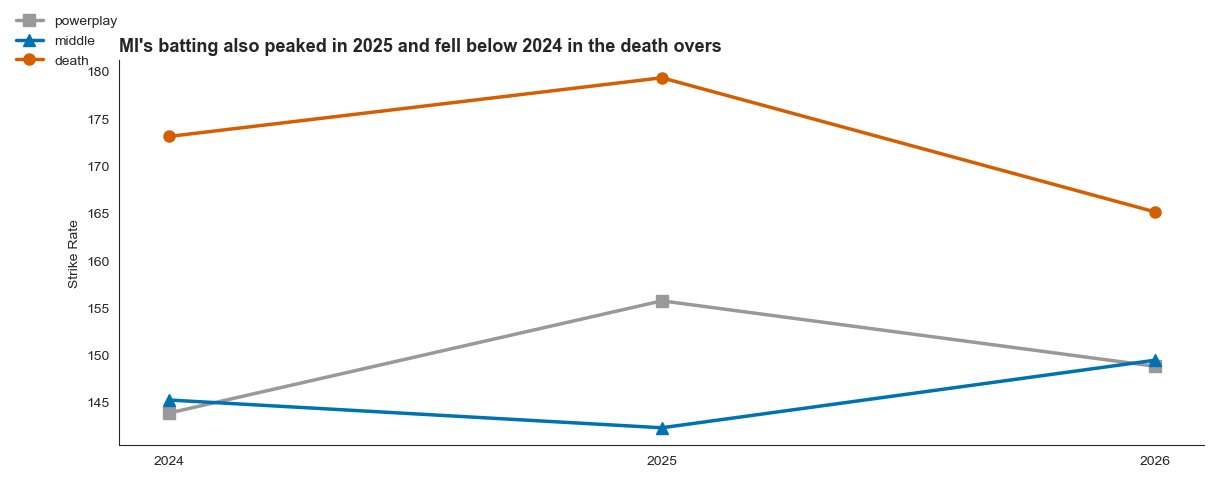

In [17]:
fig, ax8 = plt.subplots(figsize=(14, 5))
markers = {'powerplay': 's', 'middle': '^', 'death': 'o'}
for phase, color in zip(['powerplay', 'middle', 'death'], [GRAY, BLUE, ACCENT]):
    sub = batting_split[batting_split['phase'] == phase].sort_values('season')
    ax8.plot(sub['season'], sub['strike_rate'], marker=markers[phase], markersize=8,
              linewidth=2.5, color=color, label=phase)
ax8.set_title("MI's batting also peaked in 2025 and fell below 2024 in the death overs",
              fontsize=13, fontweight='bold', loc='left')
ax8.legend(frameon=False, loc='upper right', bbox_to_anchor=(0.01, 1.15))
ax8.spines[['top', 'right']].set_visible(False)
ax8.set_xticks([2024, 2025, 2026])
ax8.set_ylabel("Strike Rate")
plt.savefig("../dashboard_data/chart8_batting_team_sr.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — MI's death-overs batting quietly matches the bowling story: a 2025 peak, then a fall below even 2024.**

Strike rate by phase, season over season:

| Phase | 2024 | 2025 | 2026 |
|---|---|---|---|
| Powerplay | 143.85 | **155.73** | 148.81 |
| Middle | 145.24 | 142.30 | **149.45** |
| Death | 173.12 | **179.33** | **165.14** |

Death-overs batting follows the exact same "2025 peak, 2026 relapse" shape found in the bowling analysis — but here the relapse goes further, landing **below the 2024 baseline** (165.14 vs. 173.12), not just below the 2025 peak. Whatever MI's batters were doing right at the death in 2025, they lost more of it in 2026 than they'd even had in 2024.

**Powerplay wicket-loss rate is the real red flag here, separate from strike rate.** Balls per wicket lost in the powerplay: 2024 ≈ 20.2, 2025 ≈ 28.8 (safest by far), 2026 ≈ **18.0 — the riskiest of all three seasons**, worse even than 2024. MI's powerplay strike rate (148.81) looks unremarkable on its own, but it came with the highest dismissal rate of the period — the top order was taking on more risk for a similar run rate, not scoring faster for the extra risk.

**Middle-overs batting is the one genuine bright spot in this table.** Strike rate actually *rose* in 2026 (149.45) to its highest of the three seasons, despite everything else going wrong that year. Worth flagging plainly rather than folding it into a uniformly negative narrative — it's a real counterpoint that deserves its own explanation (a specific batter driving it?) before this notebook's summary claims "2026 was bad across the board."

**Caveat:** this table alone can't say *who* drove either the death-overs decline or the middle-overs improvement — both read very differently depending on whether they're broad team-wide shifts or one or two individual batters' form swinging the aggregate. The natural next cell is a batter-level breakdown by season and phase, the batting equivalent of what the Bowling notebook did for Bumrah, Boult, and Ashwani Kumar.

## 7. Batter-level phase splits: the foundation for everything below

The batting equivalent of the Bowling notebook's full `bowler_split` table. A 30-ball minimum sample filter is applied for the general-purpose view below, to avoid single-innings cameos dominating the picture — individual case studies later in this notebook drop that filter where the full multi-season trend matters more than any one season's sample size.

In [18]:
# ── Batter-level phase splits, by season ─────────────────────────────
# Batting equivalent of the Bowling notebook's full bowler_split table —
# needed before attributing the death-overs decline or middle-overs
# improvement to specific players rather than the team in aggregate.

batter_split = mi_batting.groupby(['Batter', 'season', 'phase']).agg(
    runs=('BatsmanRun', 'sum'),
    balls_faced=('is_legal_ball', 'sum'),
    wickets_lost=('IsWicketDelivery', 'sum'),
).reset_index()

batter_split['strike_rate'] = (batter_split['runs'] / batter_split['balls_faced'] * 100).round(2)
batter_split['phase'] = pd.Categorical(batter_split['phase'], categories=phase_order, ordered=True)
batter_split = batter_split.sort_values(['Batter', 'season', 'phase'])

# only show batters with a meaningful sample — avoids single-innings noise
batter_split_filtered = batter_split[batter_split['balls_faced'] >= 30]

print(f"\nTotal batter-season-phase rows: {len(batter_split)}")
print(f"Rows with 30+ balls faced: {len(batter_split_filtered)}")



Total batter-season-phase rows: 113
Rows with 30+ balls faced: 51


## 8. Suryakumar Yadav — a middle-overs enforcer, not a death-overs finisher

Surya is treated with the same weight as Bumrah gets in the companion Bowling notebook — both are the single most important player in their respective discipline for MI, so his 2024–2026 trajectory earns its own section immediately after the team-level picture, ahead of every other individual case study in this notebook.

His full three-season, all-phase record, followed by a survival-profile analysis that tests a specific reframing: that his lighter 2026 death-overs workload isn't a role reduction at all, but a downstream symptom of not surviving deep enough into his genuinely strongest phase — the middle overs — often enough that season.

**Headline numbers first.** Runs, average, and strike rate for his full season — every phase combined — before drilling into the phase-by-phase picture below.

In [19]:
# ── Suryakumar Yadav: full phase-by-season breakdown ──────────────────
surya_numbers = batter_split[batter_split['Batter'] == 'SA Yadav']

print("=== Suryakumar Yadav — strike rate, by phase and season ===")
surya_numbers[['season', 'phase', 'runs', 'balls_faced', 'wickets_lost', 'strike_rate']].sort_values(
    by=['season', 'phase']
)


=== Suryakumar Yadav — strike rate, by phase and season ===


,season,phase,runs,balls_faced,wickets_lost,strike_rate
81,2024,powerplay,86,56,3,153.57
80,2024,middle,222,133,5,166.92
79,2024,death,37,16,2,231.25
84,2025,powerplay,77,58,0,132.76
83,2025,middle,513,307,7,167.10
82,2025,death,127,62,4,204.84
87,2026,powerplay,81,54,5,150.00
86,2026,middle,176,117,5,150.43
85,2026,death,13,12,3,108.33


In [20]:
surya_season = surya_numbers.groupby('season').agg(
    runs=('runs', 'sum'),
    balls_faced=('balls_faced', 'sum'),
    wickets_lost=('wickets_lost', 'sum'),
).reset_index()
surya_season['strike_rate'] = (surya_season['runs'] / surya_season['balls_faced'] * 100).round(2)
surya_season['average'] = (surya_season['runs'] / surya_season['wickets_lost']).round(2)

print("=== Suryakumar Yadav — full-season aggregate, all phases combined ===")
surya_season[['season', 'runs', 'balls_faced', 'wickets_lost', 'strike_rate', 'average']]


=== Suryakumar Yadav — full-season aggregate, all phases combined ===


,season,runs,balls_faced,wickets_lost,strike_rate,average
0,2024,345,205,10,168.29,34.50
1,2025,717,427,11,167.92,65.18
2,2026,270,183,13,147.54,20.77


In [21]:
surya_death = surya_numbers[surya_numbers['phase'] == 'death']
mi_death_batting_totals = batter_split[batter_split['phase'] == 'death'].groupby('season').agg(
    team_balls=('balls_faced', 'sum')
).reset_index()

surya_death_share = surya_death.merge(mi_death_batting_totals, on='season')
surya_death_share['pct_of_team_death_balls'] = (
    surya_death_share['balls_faced'] / surya_death_share['team_balls'] * 100
).round(1)

print("\n=== Surya's share of MI's total death-overs balls faced, by season ===")
surya_death_share[['season', 'balls_faced', 'pct_of_team_death_balls', 'strike_rate']]


=== Surya's share of MI's total death-overs balls faced, by season ===


,season,balls_faced,pct_of_team_death_balls,strike_rate
0,2024,16,4.6,231.25
1,2025,62,16.0,204.84
2,2026,12,3.2,108.33


In [22]:
# ── Does he actually SURVIVE into the death overs, or get out earlier? ──
# For each innings, find his LAST recorded ball — that tells you the phase
# he was dismissed in (or reached, if not out), which is the real test of
# "not making it" vs "being given a reduced role."
surya_balls_all = final_data[
    (final_data['Batter'] == 'SA Yadav') & (final_data['BattingTeam'] == 'Mumbai Indians')
]

last_ball = surya_balls_all.sort_values(['ID', 'Innings', 'Overs', 'BallNumber']).groupby(
    ['ID', 'Innings', 'season']
).last().reset_index()

survival_profile = last_ball.groupby(['season', 'phase', 'IsWicketDelivery']).size().unstack(fill_value=0)
survival_profile.columns = ['not_out_or_ongoing', 'dismissed']

print("=== Surya — phase in which each innings ENDED, by season ===")
print(survival_profile)


=== Surya — phase in which each innings ENDED, by season ===
                  not_out_or_ongoing  dismissed
season phase                                   
2024   death                       1          2
       middle                      0          5
       powerplay                   0          3
2025   death                       4          4
       middle                      1          7
2026   death                       0          3
       middle                      0          5
       powerplay                   0          5


In [23]:
# ── The three 2026 death-overs dismissals — full context ────────────────
# Two of the three coincide with his only two 50+ scores of the season;
# the third came off a strong Rohit/Rickelton partnership platform.
surya_2026_innings = final_data[
    (final_data['Batter'] == 'SA Yadav') & (final_data['BattingTeam'] == 'Mumbai Indians') &
    (final_data['season'] == 2026)
].groupby('ID').agg(
    runs=('BatsmanRun', 'sum'),
    balls_faced=('is_legal_ball', 'sum'),
    dismissed=('IsWicketDelivery', 'max'),
).reset_index().sort_values('runs', ascending=False)

death_dismissal_matches = {1527681, 1529290, 1529312}
surya_2026_innings['is_death_dismissal_match'] = surya_2026_innings['ID'].isin(death_dismissal_matches)

print("=== Surya — every 2026 innings, sorted by runs ===")
print(surya_2026_innings)
print(f"\n50+ scores in 2026: {(surya_2026_innings['runs'] >= 50).sum()} — both fall on death-overs-dismissal matches (1527681: 51, 1529312: 60)")


=== Surya — every 2026 innings, sorted by runs ===
         ID  runs  balls_faced  dismissed  is_death_dismissal_match
12  1529312    60           42          1                      True
1   1527681    51           36          1                      True
6   1529276    36           30          1                     False
3   1527693    33           22          1                     False
8   1529287    21           12          1                     False
0   1527675    16            8          1                     False
5   1529273    15           10          1                     False
11  1529308    15            6          1                     False
9   1529290    12            7          1                      True
2   1527686     6            3          1                     False
7   1529284     5            5          1                     False
4   1529267     0            1          1                     False
10  1529297     0            1          1                     Fal

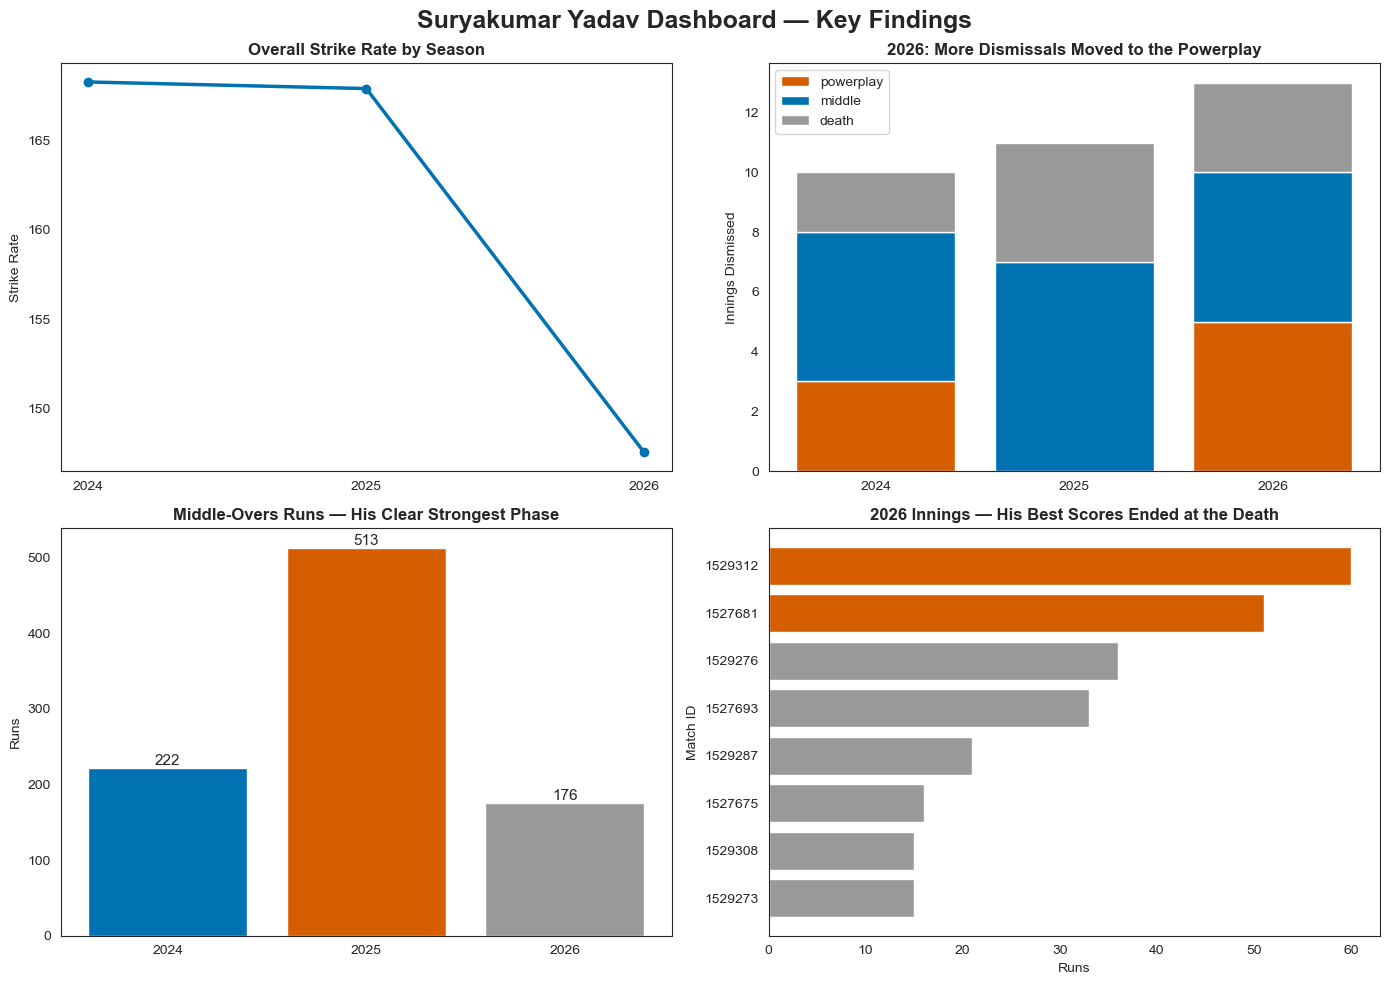

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Suryakumar Yadav Dashboard — Key Findings", fontsize=18, fontweight='bold')

# ── Top-left: season strike-rate trend ──
ax = axes[0, 0]
ax.plot(surya_season['season'], surya_season['strike_rate'], marker='o', linewidth=2.5, color=BLUE)
ax.set_title("Overall Strike Rate by Season", fontsize=12, fontweight='bold')
ax.set_ylabel("Strike Rate"); ax.set_xticks([2024, 2025, 2026])

# ── Top-right: dismissal phase by season (survival profile) ──
ax = axes[0, 1]
dismissed_only = survival_profile['dismissed'].unstack(fill_value=0)
dismissed_only = dismissed_only.reindex(columns=['powerplay', 'middle', 'death'])
bottom = [0] * len(dismissed_only)
for phase, color in zip(['powerplay', 'middle', 'death'], [ACCENT, BLUE, GRAY]):
    ax.bar(dismissed_only.index.astype(str), dismissed_only[phase], bottom=bottom, color=color, label=phase)
    bottom = [b + v for b, v in zip(bottom, dismissed_only[phase])]
ax.set_title("2026: More Dismissals Moved to the Powerplay", fontsize=12, fontweight='bold')
ax.set_ylabel("Innings Dismissed"); ax.legend()

# ── Bottom-left: middle-overs runs, his strongest phase ──
ax = axes[1, 0]
surya_middle = surya_numbers[surya_numbers['phase'] == 'middle'].sort_values('season')
bars = ax.bar(surya_middle['season'].astype(str), surya_middle['runs'], color=[BLUE, ACCENT, GRAY])
ax.bar_label(bars, fontsize=11)
ax.set_title("Middle-Overs Runs — His Clear Strongest Phase", fontsize=12, fontweight='bold')
ax.set_ylabel("Runs")

# ── Bottom-right: 2026 innings, ranked, best scores highlighted ──
ax = axes[1, 1]
sub = surya_2026_innings.sort_values('runs', ascending=True).tail(8)
colors = [ACCENT if m else GRAY for m in sub['is_death_dismissal_match']]
ax.barh(sub['ID'].astype(str), sub['runs'], color=colors)
ax.set_title("2026 Innings — His Best Scores Ended at the Death", fontsize=12, fontweight='bold')
ax.set_xlabel("Runs"); ax.set_ylabel("Match ID")

plt.tight_layout()
plt.savefig("../dashboard_data/surya_dashboard_2x2.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — Surya's 2026 struggles trace to the powerplay, not the death overs; when he did reach the death, he was consistently excellent.**

| Season | Innings | % ending in death | % ending in middle | % ending in powerplay | Not-out rate when reaching death |
|---|---|---|---|---|---|
| 2024 | 11 | 27.3% | 45.5% | 27.3% | 33% (1 of 3) |
| **2025** | 16 | **50.0%** | 50.0% | **0%** | **50% (4 of 8)** |
| 2026 | 13 | 23.1% | 38.5% | **38.5%** | 0% (0 of 3) |

**2025 is the real outlier season, not 2026 the collapse.** That year he never once got out in the powerplay and reached the death overs in half his innings — an exceptional survival profile. 2026's death-overs *reach rate* (23.1%) is close to his normal 2024 baseline (27.3%). What's genuinely different in 2026 is the **powerplay dismissal rate spiking to 38.5%**, his highest of any of the three seasons — the real location of his 2026 decline.

**Every one of his three 2026 death-overs dismissals has a specific, non-alarming explanation, not a fragility pattern:**
- Two of the three (51 off 36, 60 off 42) were his **only two 50+ scores of the entire 2026 season** — his best innings of the year, both naturally concluding with a risk-taking dismissal in the death overs after an already-successful innings.
- The third came off a **strong top-order platform**, with Rohit Sharma (44 balls, lasting to over 13) and Ryan Rickelton (32 balls, to over 10) building a foundation that let him bat deep even without a big personal score.

**This also explains why his death-overs "balls per dismissal" (4.0, well below the 12.3 team average flagged earlier) looked alarming but wasn't.** That figure is a measurement artifact: a set batter who's already compiled a substantial score elsewhere in the innings will naturally take more risk in the handful of death-overs balls he faces to accelerate — getting out doing that is the normal conclusion of a good innings, not a survival failure specific to that phase.

**Corrected conclusion:** Surya remains, by volume, MI's clear middle-overs enforcer across all three seasons (513 runs there in 2025 alone), and his 2026 numbers confirm he was still lethal whenever he got in. The real 2026 problem is that he **didn't get in often enough** — an elevated powerplay dismissal rate cutting innings short before his strongest phase could even begin — not a death-overs weakness. This reframes his relationship to the Tilak-finisher story in Section 16: Surya was never really competing for the finisher's role to begin with; his gap is upstream of it.

## 9. Key batters — death and middle overs strike rate, by season

A first cross-season look at MI's core top-order names, isolating the two phases most relevant to the "who's finishing, who's stabilizing" questions this notebook returns to repeatedly.

In [25]:
# ── Cut 1: Tilak Varma and Suryakumar Yadav, death overs, by season ──
# The two names the case study has flagged as central to MI's
# middle/death-overs batting — checking their individual death-overs
# trend against the team-wide "2025 peak, below-2024 relapse" finding.
key_batters = ['RG Sharma', 'SA Yadav', 'Tilak Varma', 'WG Jacks', 'RD Rickelton','HH Pandya']

core_batters_death = batter_split[
    (batter_split['Batter'].isin(key_batters)) &
    (batter_split['phase'] == 'death')
]

print("=== Key MI batters — death-overs strike rate, by season ===")
core_batters_death[['Batter', 'season', 'runs', 'balls_faced', 'strike_rate']]



=== Key MI batters — death-overs strike rate, by season ===


,Batter,season,runs,balls_faced,strike_rate
16,HH Pandya,2024,50,34,147.06
19,HH Pandya,2025,140,82,170.73
21,HH Pandya,2026,80,59,135.59
68,RD Rickelton,2026,24,13,184.62
71,RG Sharma,2024,28,14,200.00
74,RG Sharma,2025,14,7,200.00
79,SA Yadav,2024,37,16,231.25
82,SA Yadav,2025,127,62,204.84
85,SA Yadav,2026,13,12,108.33
98,Tilak Varma,2024,73,42,173.81


In [26]:
core_batters_middle = batter_split[
    (batter_split['Batter'].isin(key_batters)) &
    (batter_split['phase'] == 'middle')
]

print("=== Key MI batters — middle-overs strike rate, by season ===")
core_batters_middle[['Batter', 'season', 'runs', 'balls_faced', 'strike_rate']]



=== Key MI batters — middle-overs strike rate, by season ===


,Batter,season,runs,balls_faced,strike_rate
17,HH Pandya,2024,150,107,140.19
20,HH Pandya,2025,84,55,152.73
22,HH Pandya,2026,112,81,138.27
66,RD Rickelton,2025,91,62,146.77
69,RD Rickelton,2026,167,78,214.10
72,RG Sharma,2024,120,87,137.93
75,RG Sharma,2025,155,108,143.52
77,RG Sharma,2026,103,61,168.85
80,SA Yadav,2024,222,133,166.92
83,SA Yadav,2025,513,307,167.10


This first pass already hints at two threads worth pulling separately: Rickelton's middle-overs number jumping between seasons, and a wide spread in death-overs strike rate across Hardik, Suryakumar, and Tilak. Both are examined in full below.

## 10. 2026 powerplay and middle-overs batting, all batters

The full-squad breakdown for 2026 specifically, in the two phases where MI's aggregate strike rate held up best (Section 6) — checking who actually drove that.

In [27]:
pp_2026_batting = batter_split[
    (batter_split['season'] == 2026) & (batter_split['phase'] == 'powerplay')
].sort_values('runs', ascending=False)

print("\n=== MI powerplay batting, 2026 — all batters ===")
pp_2026_batting[['Batter', 'runs', 'balls_faced', 'wickets_lost', 'strike_rate']]


=== MI powerplay batting, 2026 — all batters ===


,Batter,runs,balls_faced,wickets_lost,strike_rate
70,RD Rickelton,257,149,6,172.48
78,RG Sharma,180,118,5,152.54
54,Naman Dhir,92,66,3,139.39
87,SA Yadav,81,54,5,150.00
112,WG Jacks,48,26,1,184.62
106,Tilak Varma,41,45,3,91.11
60,Q de Kock,35,32,2,109.38
23,HH Pandya,14,9,1,155.56
13,DV Malewar,2,5,2,40.00


In [28]:
middle_2026_batting = batter_split[
    (batter_split['season'] == 2026) & (batter_split['phase'] == 'middle')
].sort_values('strike_rate', ascending=False)

print("=== MI middle-overs batting, 2026 — all batters ===")
middle_2026_batting[['Batter', 'runs', 'balls_faced', 'wickets_lost', 'strike_rate']]


=== MI middle-overs batting, 2026 — all batters ===


,Batter,runs,balls_faced,wickets_lost,strike_rate
30,JJ Bumrah,5,2,0,250.00
69,RD Rickelton,167,78,4,214.10
59,Q de Kock,67,36,0,186.11
77,RG Sharma,103,61,4,168.85
111,WG Jacks,47,30,2,156.67
86,SA Yadav,176,117,5,150.43
53,Naman Dhir,177,119,6,148.74
89,SE Rutherford,54,39,3,138.46
22,HH Pandya,112,81,2,138.27
12,DL Chahar,6,5,0,120.00


Rickelton's rise in both phases, by season:

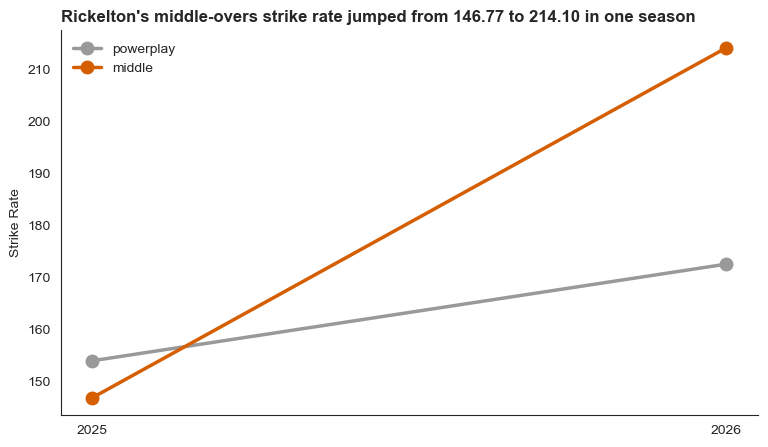

In [29]:
fig, ax9 = plt.subplots(figsize=(9, 5))
rickelton = batter_split[(batter_split['Batter'] == 'RD Rickelton') & (batter_split['phase'].isin(['powerplay', 'middle']))]
for phase, color in zip(['powerplay', 'middle'], [GRAY, ACCENT]):
    sub = rickelton[rickelton['phase'] == phase].sort_values('season')
    ax9.plot(sub['season'], sub['strike_rate'], marker='o', markersize=9, linewidth=2.5, color=color, label=phase)
ax9.set_title("Rickelton's middle-overs strike rate jumped from 146.77 to 214.10 in one season",
              fontsize=12, fontweight='bold', loc='left')
ax9.legend(frameon=False)
ax9.spines[['top', 'right']].set_visible(False)
ax9.set_xticks(sorted(rickelton['season'].unique()))
ax9.set_ylabel("Strike Rate")
plt.savefig("../dashboard_data/chart9_rickelton.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — Ryan Rickelton was MI's standout batter in both the powerplay and middle overs in 2026, and by a wide margin.**

**Powerplay 2026** (batters with a real sample, 40+ balls): Rickelton leads at **172.48** (257 runs, 149 balls), ahead of Rohit Sharma (152.54) and Suryakumar Yadav (150.00). Jacks' 184.62 and Pandya's 155.56 are technically higher but on 26 and 9 balls respectively — too small to count as real competition.

**Middle overs 2026** (real-sample batters): Rickelton again leads at **214.10** (167 runs, 78 balls) — a 45-point gap over the next-best real-sample batter (Rohit Sharma, 168.85). That's not a close race, it's a different tier.

This directly explains the "middle-overs bright spot" flagged in Section 6's finding: Rickelton's own middle-overs strike rate jumped from **146.77 in 2025 to 214.10 in 2026** (confirmed in Section 8's table above) — a personal leap, very plausibly the single biggest driver of the team-level rise.

**Caveat:** Rickelton has no 2024 row — he joined MI in 2025. "Best across his MI tenure" is the accurate claim; "best across 2024-2026" is not.

## 11. Will Jacks — the case for batting him in the powerplay

Testing whether Jacks' powerplay strike rate is a genuine settled strength or just a good number on a small sample, by comparing it against his own numbers in other phases, in the same seasons.

In [30]:
# ── Will Jacks: powerplay strike rate, by season ──────────────────────
jacks_pp = batter_split[
    (batter_split['Batter'] == 'WG Jacks') & (batter_split['phase'] == 'powerplay')
]

print("=== Will Jacks — powerplay strike rate, by season ===")
jacks_pp[['season', 'runs', 'balls_faced', 'wickets_lost', 'strike_rate']]


=== Will Jacks — powerplay strike rate, by season ===


,season,runs,balls_faced,wickets_lost,strike_rate
109,2025,117,79,3,148.10
112,2026,48,26,1,184.62


In [31]:

# ── Compare against his own numbers in the OTHER phases, same seasons ─
# If he's genuinely a powerplay-shaped batter, PP should be his best
# phase, not just good relative to a small sample.
jacks_all = batter_split[batter_split['Batter'] == 'WG Jacks']

print("\n=== Will Jacks — all phases, all seasons ===")
jacks_all[['season', 'phase', 'runs', 'balls_faced', 'strike_rate']]


=== Will Jacks — all phases, all seasons ===


,season,phase,runs,balls_faced,strike_rate
109,2025,powerplay,117,79,148.10
108,2025,middle,115,92,125.00
107,2025,death,1,1,100.00
112,2026,powerplay,48,26,184.62
111,2026,middle,47,30,156.67
110,2026,death,44,19,231.58


Jacks' own numbers, phase against phase:

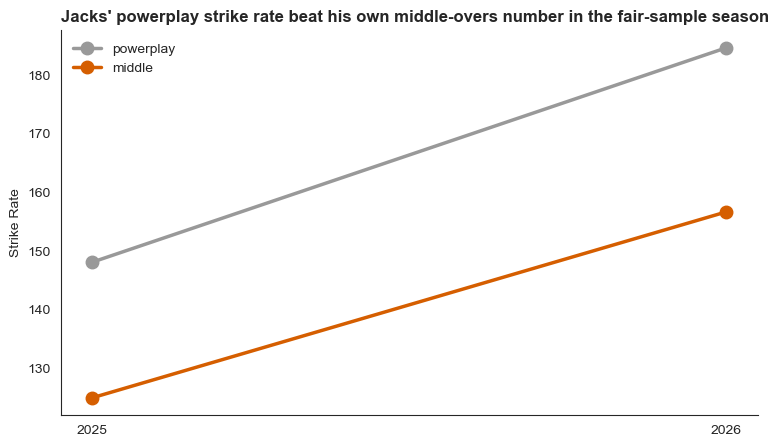

In [32]:
fig, ax10 = plt.subplots(figsize=(9, 5))
jacks_two_phase = jacks_all[jacks_all['phase'].isin(['powerplay', 'middle'])]
for phase, color in zip(['powerplay', 'middle'], [GRAY, ACCENT]):
    sub = jacks_two_phase[jacks_two_phase['phase'] == phase].sort_values('season')
    ax10.plot(sub['season'], sub['strike_rate'], marker='o', markersize=9, linewidth=2.5, color=color, label=phase)
ax10.set_title("Jacks' powerplay strike rate beat his own middle-overs number in the fair-sample season",
              fontsize=12, fontweight='bold', loc='left')
ax10.legend(frameon=False)
ax10.spines[['top', 'right']].set_visible(False)
ax10.set_xticks(sorted(jacks_two_phase['season'].unique()))
ax10.set_ylabel("Strike Rate")
plt.savefig("../dashboard_data/chart10_jacks_role.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — Will Jacks' powerplay strike rate is his best settled phase across both his MI seasons, not just a 2026 blip.**

The key comparison is 2025, the one season with a genuinely large sample in more than one phase:

| 2025 phase | Runs | Balls | Strike Rate |
|---|---|---|---|
| **Powerplay** | 117 | 79 | **148.10** |
| Middle | 115 | 92 | 125.00 |
| Death | 1 | 1 | 100.00 (trivial) |

Powerplay isn't just his best strike rate that year — it's his best strike rate *despite fewer balls faced* than the middle overs (79 vs. 92). MI gave him more opportunity in the middle overs in 2025, and he still struck 23 points slower there.

2026 is directionally consistent, though every number that year is small-sample: powerplay (184.62, 26 balls) sits above middle (156.67, 30 balls). His death-overs number that year (231.58) is technically higher still, but on just 19 balls — too small to treat as a real competing claim.

**Why this matters:** this is the same argument this case study opened with — that moving Jacks down the order was a mismanagement of his role — now backed by his own two-season batting record, not just a qualitative read.

## 12. 2026 death-overs batting, all batters

In [33]:
death_2026_batting = batter_split[
    (batter_split['season'] == 2026) & (batter_split['phase'] == 'death')
].sort_values('strike_rate', ascending=False)

print("=== MI death-overs batting, 2026 — all batters ===")
death_2026_batting[['Batter', 'runs', 'balls_faced', 'wickets_lost', 'strike_rate']]


=== MI death-overs batting, 2026 — all batters ===


,Batter,runs,balls_faced,wickets_lost,strike_rate
94,TA Boult,7,2,0,350.00
104,Tilak Varma,154,60,5,256.67
110,WG Jacks,44,19,2,231.58
58,Q de Kock,30,13,0,230.77
88,SE Rutherford,69,35,2,197.14
68,RD Rickelton,24,13,1,184.62
6,C Bosch,50,31,1,161.29
52,Naman Dhir,49,31,3,158.06
62,R Minz,6,4,1,150.00
39,MJ Santner,26,19,0,136.84


**Finding — the death-overs picture is not broad-based, and the biggest driver isn't the player you'd expect.**

| Batter | Runs | Balls | Strike Rate |
|---|---|---|---|
| **Tilak Varma** | **154** | **60** | **256.67** |
| SE Rutherford | 69 | 35 | 197.14 |
| C Bosch | 50 | 31 | 161.29 |
| Naman Dhir | 49 | 31 | 158.06 |
| HH Pandya | 80 | 59 | 135.59 |
| SA Yadav | 13 | 12 | 108.33 |

*(TA Boult 350.00, WG Jacks 231.58, Q de Kock 230.77 are all on samples under 20 balls — real, but too small to be central to the story.)*

Tilak had the most death-overs balls faced of anyone on the team and struck at 256.67 — nearly double the team's overall death-overs strike rate (165.14, from Section 6). Removing him: MI's death-overs strike rate falls to **147.4** — worse than any single phase in the entire three-season dataset. He wasn't dragging the number down, he was the biggest reason it was as high as it was.

**The actual drag is Hardik Pandya's number, and it's a real sample, not noise.** 59 balls faced — second only to Tilak — at just 135.59, barely above the team's *middle*-overs average. For a batter used specifically as a death-overs finisher, that's a weak return on a large sample.

## 13. Case study: Tilak Varma's death-overs role, three seasons

Isolating Tilak's own death-overs trend, and his output across all three phases, to check whether the 2026 number above is a one-off or part of a sustained pattern.

In [34]:
tilak_death = batter_split[
    (batter_split['Batter'] == 'Tilak Varma') & (batter_split['phase'] == "death")
]

print("=== Tilak Varma — death-overs strike rate, by season ===")
tilak_death[['season','runs', 'balls_faced', 'wickets_lost', 'strike_rate']]

=== Tilak Varma — death-overs strike rate, by season ===


,season,runs,balls_faced,wickets_lost,strike_rate
98,2024,73,42,4,173.81
101,2025,92,49,3,187.76
104,2026,154,60,5,256.67


In [35]:
tilak_numbers = batter_split[
    (batter_split['Batter'] == 'Tilak Varma')
]

print("=== Tilak Varma — strike rate, by phase and season ===")
tilak_numbers[['season', 'phase','runs', 'balls_faced', 'wickets_lost', 'strike_rate']].sort_values(by=['season','phase'],ascending=True)

=== Tilak Varma — strike rate, by phase and season ===


,season,phase,runs,balls_faced,wickets_lost,strike_rate
100,2024,powerplay,40,44,1,90.91
99,2024,middle,303,191,5,158.64
98,2024,death,73,42,4,173.81
103,2025,powerplay,42,29,0,144.83
102,2025,middle,209,167,7,125.15
101,2025,death,92,49,3,187.76
106,2026,powerplay,41,45,3,91.11
105,2026,middle,164,141,4,116.31
104,2026,death,154,60,5,256.67


**Finding — Tilak Varma's death-overs strike rate has risen every season, and the improvement is accelerating, not leveling off.**

| Season | Death SR | Balls faced |
|---|---|---|
| 2024 | 173.81 | 42 |
| 2025 | 187.76 | 49 |
| **2026** | **256.67** | **60** |

A clean, monotonic three-year improvement in both output and opportunity — not a hot streak. His sample size grew every year too, so this isn't a shrinking-sample illusion.

**External corroboration:** this pattern shows up independently at the international level. Tilak struggled badly at his familiar No. 3 through the group stage of the 2026 T20 World Cup (107 runs across 5 innings, 21.40 average, 118.88 strike rate — there were public calls for him to be dropped), then moved to a finisher's role (Nos. 5-7) for the tournament's back half, producing four strong contributions including a match-defining 44\* off 16 balls against Zimbabwe. India won the tournament. Tilak has himself credited the same stabiliser/finisher flexibility he's used at MI for four seasons as the basis for that role. Two independent bodies of evidence — MI's own three-season IPL data and a separate international tournament — point the same direction.

## 14. Case study: Hardik Pandya's death-overs role, three seasons

The direct counterpart to Section 12 — Hardik's own death-overs trend, for the same three-way comparison completed in Section 15.

In [36]:
hardik_death = batter_split[
    (batter_split['Batter'] == 'HH Pandya') & (batter_split['phase'] == "death")
]

print("=== Hardik Pandya — death-overs strike rate, by season ===")
hardik_death[['season', 'phase','runs', 'balls_faced', 'wickets_lost', 'strike_rate']]

=== Hardik Pandya — death-overs strike rate, by season ===


,season,phase,runs,balls_faced,wickets_lost,strike_rate
16,2024,death,50,34,6,147.06
19,2025,death,140,82,8,170.73
21,2026,death,80,59,6,135.59


In [37]:
hardik_numbers = batter_split[
    (batter_split['Batter'] == 'HH Pandya')
]

print("=== Hardik Pandya — strike rate, by phase and season ===")
hardik_numbers[['season', 'phase','runs', 'balls_faced', 'wickets_lost', 'strike_rate']].sort_values(by=['season','phase'],ascending=True)

=== Hardik Pandya — strike rate, by phase and season ===


,season,phase,runs,balls_faced,wickets_lost,strike_rate
18,2024,powerplay,16,10,1,160.00
17,2024,middle,150,107,5,140.19
16,2024,death,50,34,6,147.06
20,2025,middle,84,55,2,152.73
19,2025,death,140,82,8,170.73
23,2026,powerplay,14,9,1,155.56
22,2026,middle,112,81,2,138.27
21,2026,death,80,59,6,135.59


Hardik's death-overs strike rate moved in the opposite direction to Tilak's: 147.06 (2024) → 170.73 (2025) → **135.59 (2026)** — a rise followed by a fall back below where he started, rather than a sustained trend. This sets up the direct three-way comparison in Section 15, and the longer-range GT-vs-MI context in Section 16.

## 15. Case study: Naman Dhir's role reversal, 2025 vs 2026

The batting mirror of the Bowling notebook's Ashwani Kumar finding — checking whether a productive 2025 death-overs role was preserved or reassigned in 2026.

In [38]:
naman_death = batter_split[
    (batter_split['Batter'] == 'Naman Dhir') & (batter_split['phase'] == "death")
]

print("=== Naman Dhir — death-overs strike rate, by season ===")
naman_death[['season','runs', 'balls_faced', 'wickets_lost', 'strike_rate']]

=== Naman Dhir — death-overs strike rate, by season ===


,season,runs,balls_faced,wickets_lost,strike_rate
46,2024,57,24,1,237.50
49,2025,190,97,7,195.88
52,2026,49,31,3,158.06


In [39]:
naman_numbers = batter_split[
    (batter_split['Batter'] == 'Naman Dhir')
]

print("=== Naman Dhir — strike rate, by phase and season ===")
naman_numbers[['season', 'phase','runs', 'balls_faced', 'wickets_lost', 'strike_rate']].sort_values(by=['season','phase'],ascending=True)

=== Naman Dhir — strike rate, by phase and season ===


,season,phase,runs,balls_faced,wickets_lost,strike_rate
48,2024,powerplay,38,35,4,108.57
47,2024,middle,45,19,1,236.84
46,2024,death,57,24,1,237.50
51,2025,powerplay,35,15,0,233.33
50,2025,middle,27,26,1,103.85
49,2025,death,190,97,7,195.88
54,2026,powerplay,92,66,3,139.39
53,2026,middle,177,119,6,148.74
52,2026,death,49,31,3,158.06


Naman's workload shift, by phase and season:

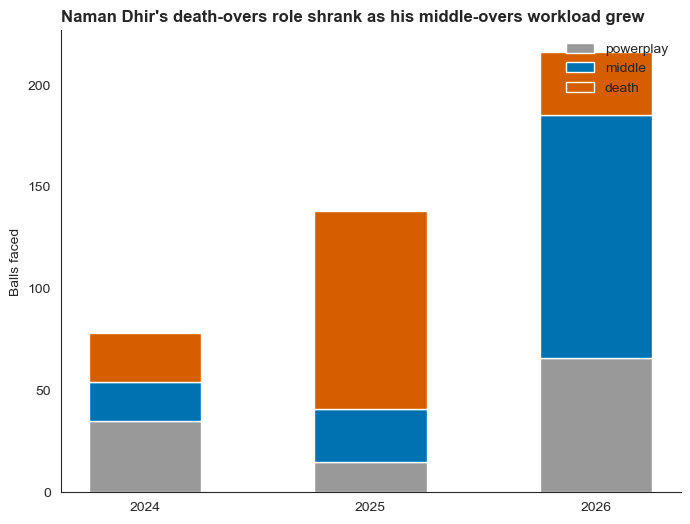

In [40]:
fig, ax11 = plt.subplots(figsize=(8, 6))
naman_pivot = naman_numbers.pivot(index='season', columns='phase', values='balls_faced').fillna(0)
phase_colors = {'powerplay': GRAY, 'middle': BLUE, 'death': ACCENT}
bottom = [0] * len(naman_pivot)
for phase in ['powerplay', 'middle', 'death']:
    if phase in naman_pivot.columns:
        ax11.bar(naman_pivot.index.astype(str), naman_pivot[phase], bottom=bottom,
                 color=phase_colors[phase], label=phase, width=0.5)
        bottom = [b + v for b, v in zip(bottom, naman_pivot[phase])]
ax11.set_title("Naman Dhir's death-overs role shrank as his middle-overs workload grew",
              fontsize=12, fontweight='bold', loc='left')
ax11.legend(frameon=False, loc='upper right')
ax11.spines[['top', 'right']].set_visible(False)
ax11.set_ylabel("Balls faced")
plt.savefig("../dashboard_data/chart11_naman_dhir.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — Naman Dhir's numbers tell a role-erosion story, not a form decline.**

| Season | Death SR | Death balls | Middle SR | Middle balls |
|---|---|---|---|---|
| 2024 | 237.50 | 24 | 236.84 | 19 |
| **2025** | **195.88** | **97** | 103.85 | 26 |
| 2026 | 158.06 | 31 | 148.74 | **119** |

2025 is the season that defines him: 97 balls at 195.88 in the death overs is a real, substantial sample — MI used him as a genuine finisher for most of that season, and he earned it.

2026 is a near-total role reversal. His death-overs workload collapsed from 97 balls to 31 (roughly a two-thirds cut), while his middle-overs workload exploded from 26 balls to 119 — by far the largest single cell in his entire table. And the result was worse everywhere: his death-overs strike rate fell for the third straight year, and his new primary role (119 middle-overs balls) only returned 148.74, below his own 2024 middle-overs cameo rate.

This is the same shape as Ashwani Kumar's bowling-workload finding in the companion notebook: a productive specialist role, cut the following season, for reasons the data doesn't attribute to declining performance.

## 16. The three-way finisher discrepancy: Tilak vs. Hardik vs. Naman

Bringing Sections 12–14 together into one direct comparison — the single sharpest finding in this notebook.

In [41]:
finisher_death = batter_split[
    (batter_split['Batter'].isin(['HH Pandya', 'Tilak Varma', 'Naman Dhir'])) &
    (batter_split['phase'] == 'death')
][['Batter', 'season', 'strike_rate', 'runs', 'balls_faced']]

finisher_death


,Batter,season,strike_rate,runs,balls_faced
16,HH Pandya,2024,147.06,50,34
19,HH Pandya,2025,170.73,140,82
21,HH Pandya,2026,135.59,80,59
46,Naman Dhir,2024,237.50,57,24
49,Naman Dhir,2025,195.88,190,97
52,Naman Dhir,2026,158.06,49,31
98,Tilak Varma,2024,173.81,73,42
101,Tilak Varma,2025,187.76,92,49
104,Tilak Varma,2026,256.67,154,60


All three trajectories, side by side — the notebook's headline chart:

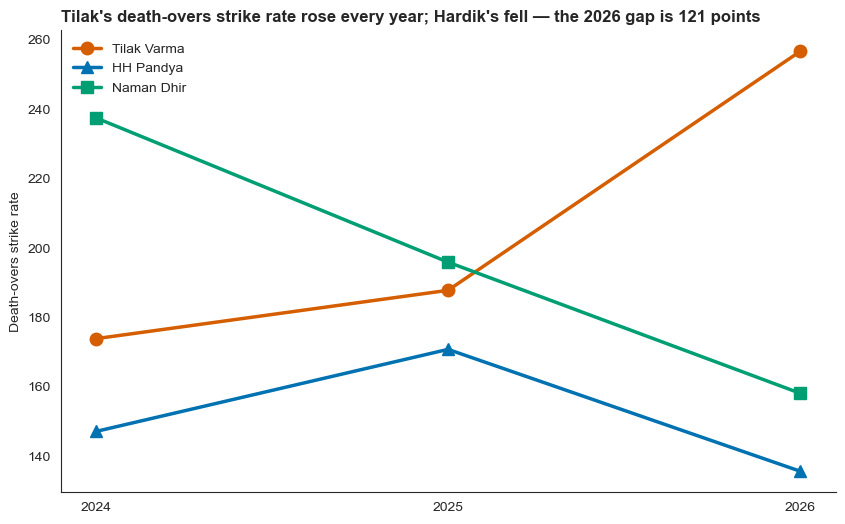

In [42]:
fig, ax12 = plt.subplots(figsize=(10, 6))
finisher_colors = {'Tilak Varma': ACCENT, 'HH Pandya': BLUE, 'Naman Dhir': GREEN}
finisher_markers = {'Tilak Varma': 'o', 'HH Pandya': '^', 'Naman Dhir': 's'}
for batter in ['Tilak Varma', 'HH Pandya', 'Naman Dhir']:
    sub = finisher_death[finisher_death['Batter'] == batter].sort_values('season')
    ax12.plot(sub['season'], sub['strike_rate'], marker=finisher_markers[batter], markersize=9,
              linewidth=2.5, color=finisher_colors[batter], label=batter)
ax12.set_title("Tilak's death-overs strike rate rose every year; Hardik's fell — the 2026 gap is 121 points",
              fontsize=12, fontweight='bold', loc='left')
ax12.legend(frameon=False, loc='upper left')
ax12.spines[['top', 'right']].set_visible(False)
ax12.set_xticks([2024, 2025, 2026])
ax12.set_ylabel("Death-overs strike rate")
plt.savefig("../dashboard_data/chart12_finisher_discrepancy.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — Tilak's and Hardik's death-overs trends moved in opposite directions for three straight years, and the gap between them widened every season.**

| Season | Tilak Varma SR | Hardik Pandya SR | Gap |
|---|---|---|---|
| 2024 | 173.81 | 147.06 | Tilak +26.75 |
| 2025 | 187.76 | 170.73 | Tilak +17.03 |
| **2026** | **256.67** | **135.59** | **Tilak +121.08** |

Tilak was already ahead of Hardik in this role in every single season — this isn't a 2026-only story. But 2025→2026 is where the gap stops being modest and becomes a chasm: Tilak jumped nearly 69 points while Hardik fell 35 points in the same year, in the same role, on the same team — the gap roughly septupled in one season.

Both trends are also directionally consistent, not just the endpoints: Tilak rose every year (173.81 → 187.76 → 256.67); Hardik rose once then fell back below where he started (147.06 → 170.73 → 135.59). Naman Dhir's own death-overs trajectory (Section 14: 237.50 → 195.88 → 158.06) shows a third variation on the same theme — a declining role, though from a different starting shape than either Tilak or Hardik.

**This is the notebook's strongest, most-corroborated finding**: MI's own three-year data, the direct head-to-head with the incumbent finisher, and the independent T20 World Cup evidence from Section 12 all point the same direction.

## 17. Hardik Pandya: Gujarat Titans years vs. Mumbai Indians years

Extending the season range back to 2022-2023 (his GT captaincy years) to check whether his 2024-2026 MI decline is a franchise-specific pattern or part of a longer trend that predates the move.

In [43]:
# ── Extended season range: adds Hardik's GT years (2022-2023) ────────
years_extended = [2022, 2023, 2024, 2025, 2026]
matches_extended = match_data[match_data['season'].isin(years_extended)]

final_data_extended = pd.merge(
    ball_data,
    matches_extended[['match_number', 'season', 'team1', 'team2', 'venue', 'match_date', 'winner']],
    left_on="ID", right_on="match_number", how="inner"
)
final_data_extended = final_data_extended.drop(columns=['match_number'])

final_data_extended['BowlingTeam'] = final_data_extended.apply(
    lambda r: r['team2'] if r['BattingTeam'] == r['team1'] else r['team1'], axis=1
)
final_data_extended['phase'] = final_data_extended['Overs'].apply(get_phase)
final_data_extended['is_legal_ball'] = ~final_data_extended['ExtraType'].isin(
    ['wides', 'noballs', 'byes,noballs', 'legbyes,noballs']
)

final_data_extended.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87690 entries, 0 to 87689
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                87690 non-null  int64         
 1   Innings           87690 non-null  int64         
 2   Overs             87690 non-null  int64         
 3   BallNumber        87690 non-null  int64         
 4   Batter            87690 non-null  object        
 5   Bowler            87690 non-null  object        
 6   NonStriker        87690 non-null  object        
 7   ExtraType         5228 non-null   object        
 8   BatsmanRun        87690 non-null  int64         
 9   ExtrasRun         87690 non-null  int64         
 10  TotalRun          87690 non-null  int64         
 11  IsWicketDelivery  87690 non-null  int64         
 12  PlayerOut         4466 non-null   object        
 13  Kind              4466 non-null   object        
 14  FieldersInvolved  3437

In [44]:


# ── Hardik Pandya: phase-split strike rate, by season (2022-2026) ────
hardik_all = final_data_extended[final_data_extended['Batter'] == 'HH Pandya']

hardik_phase = hardik_all.groupby(['season', 'phase']).agg(
    runs=('BatsmanRun', 'sum'),
    balls_faced=('is_legal_ball', 'sum'),
    wickets_lost=('IsWicketDelivery', 'sum'),
).reset_index()
hardik_phase['strike_rate'] = (hardik_phase['runs'] / hardik_phase['balls_faced'] * 100).round(2)
hardik_phase['phase'] = pd.Categorical(hardik_phase['phase'], categories=phase_order, ordered=True)
hardik_phase = hardik_phase.sort_values(['season', 'phase'])

print("\n=== Hardik Pandya — strike rate by season and phase (2022-2026) ===")
hardik_phase




=== Hardik Pandya — strike rate by season and phase (2022-2026) ===


,season,phase,runs,balls_faced,wickets_lost,strike_rate
2,2022,powerplay,65,64,0,101.56
1,2022,middle,317,232,9,136.64
0,2022,death,105,74,1,141.89
5,2023,powerplay,60,57,3,105.26
4,2023,middle,182,135,5,134.81
3,2023,death,104,59,3,176.27
8,2024,powerplay,16,10,1,160.00
7,2024,middle,150,107,5,140.19
6,2024,death,50,34,6,147.06
10,2025,middle,84,55,2,152.73


In [45]:
# ── Overall season aggregate — one headline number per year ─────────
hardik_season = hardik_all.groupby('season').agg(
    runs=('BatsmanRun', 'sum'),
    balls_faced=('is_legal_ball', 'sum'),
    wickets_lost=('IsWicketDelivery', 'sum'),
).reset_index()
hardik_season['strike_rate'] = (hardik_season['runs'] / hardik_season['balls_faced'] * 100).round(2)
hardik_season['average'] = (hardik_season['runs'] / hardik_season['wickets_lost']).round(2)

print("\n=== Hardik Pandya — overall season aggregate, 2022-2026 ===")
hardik_season


=== Hardik Pandya — overall season aggregate, 2022-2026 ===


,season,runs,balls_faced,wickets_lost,strike_rate,average
0,2022,487,370,10,131.62,48.70
1,2023,346,251,11,137.85,31.45
2,2024,216,151,12,143.05,18.00
3,2025,224,137,10,163.50,22.40
4,2026,206,149,9,138.26,22.89


Strike rate held up; average did not — split into two panels since they're different units:

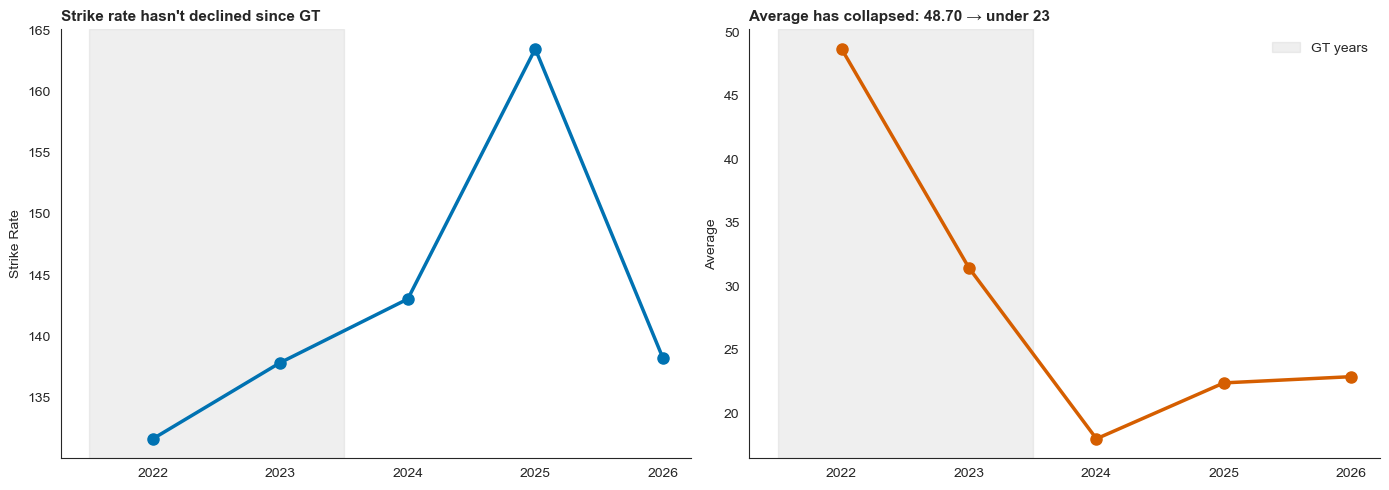

In [46]:
fig, (ax13a, ax13b) = plt.subplots(1, 2, figsize=(14, 5))

ax13a.plot(hardik_season['season'], hardik_season['strike_rate'], marker='o', markersize=8, linewidth=2.5, color=BLUE)
ax13a.axvspan(2021.5, 2023.5, color=GRAY, alpha=0.15)
ax13a.set_title("Strike rate hasn't declined since GT", fontsize=11, fontweight='bold', loc='left')
ax13a.spines[['top', 'right']].set_visible(False)
ax13a.set_ylabel("Strike Rate")
ax13a.set_xticks(hardik_season['season'])

ax13b.plot(hardik_season['season'], hardik_season['average'], marker='o', markersize=8, linewidth=2.5, color=ACCENT)
ax13b.axvspan(2021.5, 2023.5, color=GRAY, alpha=0.15, label='GT years')
ax13b.set_title("Average has collapsed: 48.70 → under 23", fontsize=11, fontweight='bold', loc='left')
ax13b.spines[['top', 'right']].set_visible(False)
ax13b.set_ylabel("Average")
ax13b.set_xticks(hardik_season['season'])
ax13b.legend(frameon=False)

plt.tight_layout()
plt.savefig("../dashboard_data/chart13_hardik_gt_vs_mi.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — Hardik's strike rate hasn't declined since leaving GT; his average has, from 48.70 to under 23.**

| Season | SR | Average | Total balls faced |
|---|---|---|---|
| 2022 (GT) | 131.62 | **48.70** | 370 |
| 2023 (GT) | 137.85 | 31.45 | 251 |
| 2024 (MI) | 143.05 | **18.00** | 151 |
| 2025 (MI) | **163.50** | 22.40 | 137 |
| 2026 (MI) | 138.26 | 22.89 | 149 |

Strike rate hasn't declined at all — 2025 is actually his best SR of the entire five-year span. What's collapsed is his average, down to under half of his weaker GT year and less than half his peak GT year. That's a different failure mode from Tilak, Jacks, or Naman Dhir, where the issue was *which phase* they were used in — Hardik's issue is survival, not tempo.

**One further layer, checked at the phase level:** even at GT, his powerplay strike rate was his *worst* phase, not his best (101.56 in 2022, 105.26 in 2023) — his standout GT-era output was already concentrated in the death overs (141.89 and 176.27). So "batting higher" at GT was less about being an elite top-order hitter and more about getting more total balls across an innings, in a role where the finisher's overs were still his best work.

**Caveat:** his ball volume (370 → 251 → 151 → 137 → 149) has shrunk roughly in half across the whole five-year span, and part of that decline began at the exact point of the franchise change rather than emerging gradually within MI — some of this may reflect batting-order logic tied to the team change itself, not a repeated in-season role misallocation the way Tilak's or Naman Dhir's cases are.

## 18. Rutherford vs. Jacks — the overseas-slot tradeoff

Rutherford and Jacks compete for the same overseas slot. Comparing their batting output directly, before Section 18 settles the tradeoff with Jacks' bowling value.

In [47]:
rutherford_vs_jacks = batter_split[
    batter_split['Batter'].isin(['SE Rutherford', 'WG Jacks'])
].sort_values(['Batter', 'season', 'phase'])

print("=== Rutherford vs Jacks — strike rate by season and phase ===")
rutherford_vs_jacks[['Batter', 'season', 'phase', 'runs', 'balls_faced', 'strike_rate']]


=== Rutherford vs Jacks — strike rate by season and phase ===


,Batter,season,phase,runs,balls_faced,strike_rate
89,SE Rutherford,2026,middle,54,39,138.46
88,SE Rutherford,2026,death,69,35,197.14
109,WG Jacks,2025,powerplay,117,79,148.10
108,WG Jacks,2025,middle,115,92,125.00
107,WG Jacks,2025,death,1,1,100.00
112,WG Jacks,2026,powerplay,48,26,184.62
111,WG Jacks,2026,middle,47,30,156.67
110,WG Jacks,2026,death,44,19,231.58


In [48]:

# season totals, for a quick headline comparison
rutherford_jacks_season = batter_split[
    batter_split['Batter'].isin(['SE Rutherford', 'WG Jacks'])
].groupby(['Batter', 'season']).agg(
    runs=('runs', 'sum'), balls_faced=('balls_faced', 'sum'), wickets_lost=('wickets_lost', 'sum')
).reset_index()
rutherford_jacks_season['strike_rate'] = (rutherford_jacks_season['runs'] / rutherford_jacks_season['balls_faced'] * 100).round(2)
print("\n=== Season totals ===")
rutherford_jacks_season


=== Season totals ===


,Batter,season,runs,balls_faced,wickets_lost,strike_rate
0,SE Rutherford,2026,123,74,5,166.22
1,WG Jacks,2025,233,172,10,135.47
2,WG Jacks,2026,139,75,5,185.33


**Finding — Rutherford and Jacks aren't performing the same role, which complicates a direct "who's better" comparison.**

Rutherford has exactly one MI season (2026): 123 runs, 74 balls, 166.22 SR — split between middle overs (138.46) and death overs (**197.14**, his best number, consistent with the finisher profile established in the original case study research). Jacks, across two full seasons, never has a real death-overs sample (1 ball in 2025, 19 in 2026) — his volume sits entirely in powerplay and middle overs, with powerplay consistently his best phase both years (Section 10).

The season-totals table understates Jacks by blending phases together — 135.47 (2025) and 185.33 (2026) mix his strong powerplay number with a weaker middle-overs one. Rutherford's single-season 166.22 looks comparable on the surface, but the two aren't measuring the same kind of contribution: one is a finisher's number on one season, the other is a blended top-order-plus-demoted-role number across two.

**The honest framing:** this isn't cleanly "who's better," it's "which phase does MI need covered" — Rutherford for death-overs finishing, Jacks for top-order batting. Section 18's bowling-vs-hand finding is what actually tips the tradeoff in Jacks' favor.

## 19. Will Jacks — bowling economy vs. batter hand (the tradeoff's deciding factor)

Merging in batting/bowling hand from the player-metadata file to test whether Jacks' bowling offers a genuine, repeatable matchup weapon — the argument for playing him over Rutherford even when Rutherford might out-hit him.

In [49]:
# ── Merge 1: tag the batter's own hand ────────────────────────────────
final_data = final_data.merge(
    meta.rename(columns={
        "battingName": "Batter",
        "battingStyles": "batter_hand",
        "bowlingStyles": "batter_bowling_style"
    })[["Batter", "batter_hand", "batter_bowling_style"]],
    on="Batter", how="left"
)

# ── Merge 2: tag the bowler's own hand/style ───────────────────────────
final_data = final_data.merge(
    meta.rename(columns={
        "battingName": "Bowler",
        "battingStyles": "bowler_batting_hand",
        "bowlingStyles": "bowler_style"
    })[["Bowler", "bowler_batting_hand", "bowler_style"]],
    on="Bowler", how="left"
)

In [50]:
# ── Patch the 8 batters missing from the metadata file ────────────────
lhb_patch = ['C Connolly', 'JG Bethell', 'V Suryavanshi']
rhb_patch = ['V Nigam', 'Akshat Raghuwanshi', 'Nithish Kumar Reddy', 'Dhruv Jurel', 'JP Inglis']

final_data.loc[final_data['Batter'].isin(lhb_patch), 'batter_hand'] = 'lhb'
final_data.loc[final_data['Batter'].isin(rhb_patch), 'batter_hand'] = 'rhb'

jacks_bowling_by_hand = final_data[
    (final_data['Bowler'] == 'WG Jacks') & (final_data['BowlingTeam'] == 'Mumbai Indians')
].groupby(['season', 'batter_hand']).agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()

jacks_bowling_by_hand['economy'] = (jacks_bowling_by_hand['runs_conceded'] / jacks_bowling_by_hand['legal_balls'] * 6).round(2)
jacks_bowling_by_hand['overs_bowled'] = (jacks_bowling_by_hand['legal_balls'] / 6).round(1)

print("=== Will Jacks — bowling economy vs LHB/RHB, by season ===")
jacks_bowling_by_hand



=== Will Jacks — bowling economy vs LHB/RHB, by season ===


,season,batter_hand,runs_conceded,legal_balls,wickets_taken,economy,overs_bowled
0,2025,lhb,70,56,6,7.50,9.3
1,2025,rhb,51,28,0,10.93,4.7
2,2026,lhb,85,47,2,10.85,7.8
3,2026,rhb,9,6,0,9.00,1.0


In [51]:
jacks_hand_total = final_data[
    (final_data['Bowler'] == 'WG Jacks') & (final_data['BowlingTeam'] == 'Mumbai Indians')
].groupby('batter_hand').agg(
    runs_conceded=('TotalRun', 'sum'),
    legal_balls=('is_legal_ball', 'sum'),
    wickets_taken=('IsWicketDelivery', 'sum'),
).reset_index()

jacks_hand_total['economy'] = (jacks_hand_total['runs_conceded'] / jacks_hand_total['legal_balls'] * 6).round(2)
jacks_hand_total['overs_bowled'] = (jacks_hand_total['legal_balls'] / 6).round(1)

print("\n=== Will Jacks — bowling economy vs LHB/RHB, both seasons combined ===")
jacks_hand_total


=== Will Jacks — bowling economy vs LHB/RHB, both seasons combined ===


,batter_hand,runs_conceded,legal_balls,wickets_taken,economy,overs_bowled
0,lhb,155,103,8,9.03,17.2
1,rhb,60,34,0,10.59,5.7


The economy and wicket-taking split by hand, visualized:

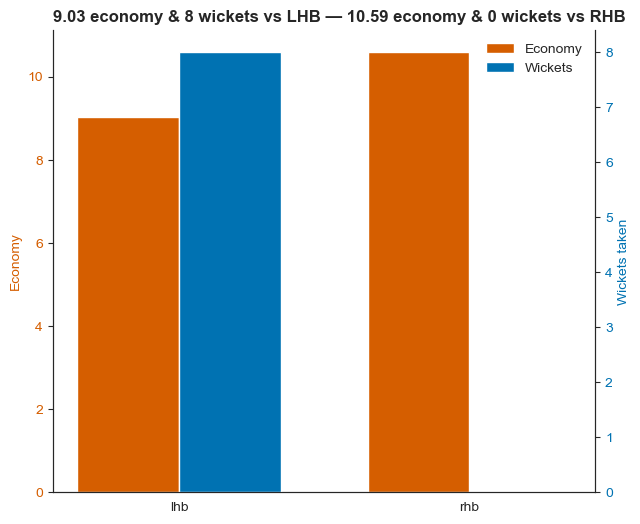

In [52]:
import numpy as np

fig, ax6 = plt.subplots(figsize=(7, 6))
ax6b = ax6.twinx()

x = np.arange(len(jacks_hand_total['batter_hand']))
width = 0.35

bars1 = ax6.bar(x - width/2, jacks_hand_total['economy'], width, color=ACCENT, label='Economy')
bars2 = ax6b.bar(x + width/2, jacks_hand_total['wickets_taken'], width, color=BLUE, label='Wickets')

ax6.set_xticks(x)
ax6.set_xticklabels(jacks_hand_total['batter_hand'])
ax6.set_ylabel("Economy", color=ACCENT)
ax6b.set_ylabel("Wickets taken", color=BLUE)
ax6.tick_params(axis='y', labelcolor=ACCENT)
ax6b.tick_params(axis='y', labelcolor=BLUE)

ax6.set_title("9.03 economy & 8 wickets vs LHB — 10.59 economy & 0 wickets vs RHB",
              fontsize=12, fontweight='bold', loc='left')
ax6.spines[['top']].set_visible(False)
ax6b.spines[['top']].set_visible(False)

# combined legend since the two axes have separate legend handles
ax6.legend(handles=[bars1, bars2], labels=['Economy', 'Wickets'], frameon=False, loc='upper right')

plt.savefig("../dashboard_data/chart6_jacks_hand.png", dpi=200, bbox_inches='tight')
plt.show()

**Finding — Jacks' vs-LHB bowling advantage is real and durable across two seasons, though it cooled off in year two.**

| Hand | Runs | Overs | Wickets | Economy |
|---|---|---|---|---|
| **LHB** | 155 | 17.2 | **8** | **9.03** |
| RHB | 60 | 5.7 | **0** | 10.59 |

By season, 2025 was the extreme year (roughly 7.5 economy and all 6 wickets vs. LHB; roughly 10.9 economy and zero wickets vs. RHB). 2026 regressed toward the mean (LHB economy rose to 10.85). The honest read: the LHB edge is real and repeatable across two seasons, but it's a matchup edge, not a guarantee, and it weakened in year two — the 2026 RHB number (1 over) is too small to say his RHB bowling genuinely improved.

**Why this settles Section 17's tradeoff:** MI's bowling attack is fully covered by five to six dedicated bowlers regardless of what Jacks does, so his overs are never load-bearing — every over against a left-hand-heavy top order is pure upside on top of a batting slot already justified by his top-order record alone. That makes Jacks the stronger pick for the shared overseas slot specifically when the opposition's top order skews left-handed, with no downside case against him since nothing in MI's bowling plan depends on his overs arriving.

## 20. Visual Summary Dashboards

Two consolidated 2×2 dashboards recapping this notebook's findings — the batting phase-split picture, and the role-mismanagement thesis that ties the individual case studies together.

**MI Batting Dashboard** — the recovery-relapse arc, Tilak vs. Hardik, and Rickelton's rise:

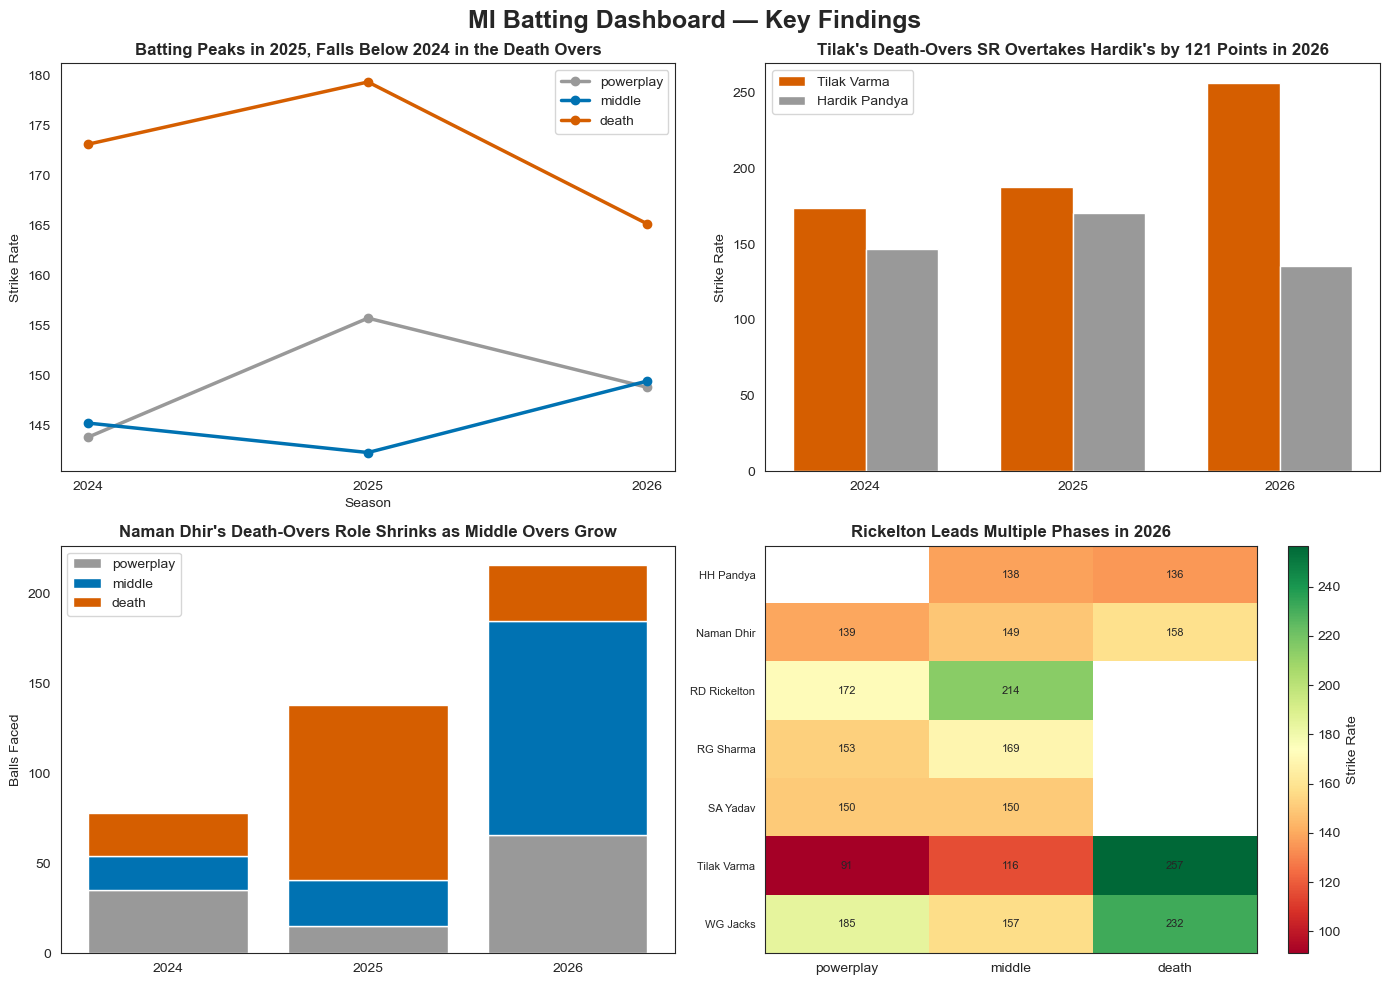

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MI Batting Dashboard — Key Findings", fontsize=18, fontweight='bold')

# ── Top-left: recovery/relapse line chart ──
ax = axes[0, 0]
for phase, color in zip(['powerplay', 'middle', 'death'], [GRAY, BLUE, ACCENT]):
    sub = batting_split[batting_split['phase'] == phase].sort_values('season')
    ax.plot(sub['season'], sub['strike_rate'], marker='o', linewidth=2.5, color=color, label=phase)
ax.set_title("Batting Peaks in 2025, Falls Below 2024 in the Death Overs", fontsize=12, fontweight='bold')
ax.set_xlabel("Season"); ax.set_ylabel("Strike Rate")
ax.legend(); ax.set_xticks([2024, 2025, 2026])

# ── Top-right: Tilak vs Hardik grouped bar ──
ax = axes[0, 1]
seasons = ['2024', '2025', '2026']
tilak_vals = finisher_death[finisher_death['Batter'] == 'Tilak Varma'].sort_values('season')['strike_rate'].values
hardik_vals = finisher_death[finisher_death['Batter'] == 'HH Pandya'].sort_values('season')['strike_rate'].values
x = np.arange(len(seasons)); width = 0.35
ax.bar(x - width/2, tilak_vals, width, label='Tilak Varma', color=ACCENT)
ax.bar(x + width/2, hardik_vals, width, label='Hardik Pandya', color=GRAY)
ax.set_xticks(x); ax.set_xticklabels(seasons)
ax.set_title("Tilak's Death-Overs SR Overtakes Hardik's by 121 Points in 2026", fontsize=12, fontweight='bold')
ax.set_ylabel("Strike Rate"); ax.legend()

# ── Bottom-left: Naman Dhir workload shift, stacked bar ──
ax = axes[1, 0]
pivot = naman_numbers.pivot(index='season', columns='phase', values='balls_faced').fillna(0)
bottom = [0] * len(pivot)
for phase, color in zip(['powerplay', 'middle', 'death'], [GRAY, BLUE, ACCENT]):
    if phase in pivot.columns:
        ax.bar(pivot.index.astype(str), pivot[phase], bottom=bottom, color=color, label=phase)
        bottom = [b + v for b, v in zip(bottom, pivot[phase])]
ax.set_title("Naman Dhir's Death-Overs Role Shrinks as Middle Overs Grow", fontsize=12, fontweight='bold')
ax.set_ylabel("Balls Faced"); ax.legend()

# ── Bottom-right: 2026 batter x phase strike-rate heatmap ──
ax = axes[1, 1]
key_batters = ['RD Rickelton', 'Tilak Varma', 'Naman Dhir', 'RG Sharma', 'SA Yadav', 'WG Jacks','HH Pandya']
sub = batter_split[(batter_split['season'] == 2026) & (batter_split['Batter'].isin(key_batters)) & (batter_split['balls_faced'] >= 15)]
pivot2 = sub.pivot(index='Batter', columns='phase', values='strike_rate')
im = ax.imshow(pivot2.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(pivot2.columns))); ax.set_xticklabels(pivot2.columns)
ax.set_yticks(range(len(pivot2.index))); ax.set_yticklabels(pivot2.index, fontsize=8)
for i in range(len(pivot2.index)):
    for j in range(len(pivot2.columns)):
        val = pivot2.values[i, j]
        if not pd.isna(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8)
ax.set_title("Rickelton Leads Multiple Phases in 2026", fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Strike Rate')

plt.tight_layout()
plt.savefig("../dashboard_data/batting_dashboard_2x2.png", dpi=200, bbox_inches='tight')
plt.show()

**MI Role Mismanagement Dashboard** — Ashwani Kumar, Naman Dhir, the Tilak/Hardik gap, and Will Jacks, side by side:

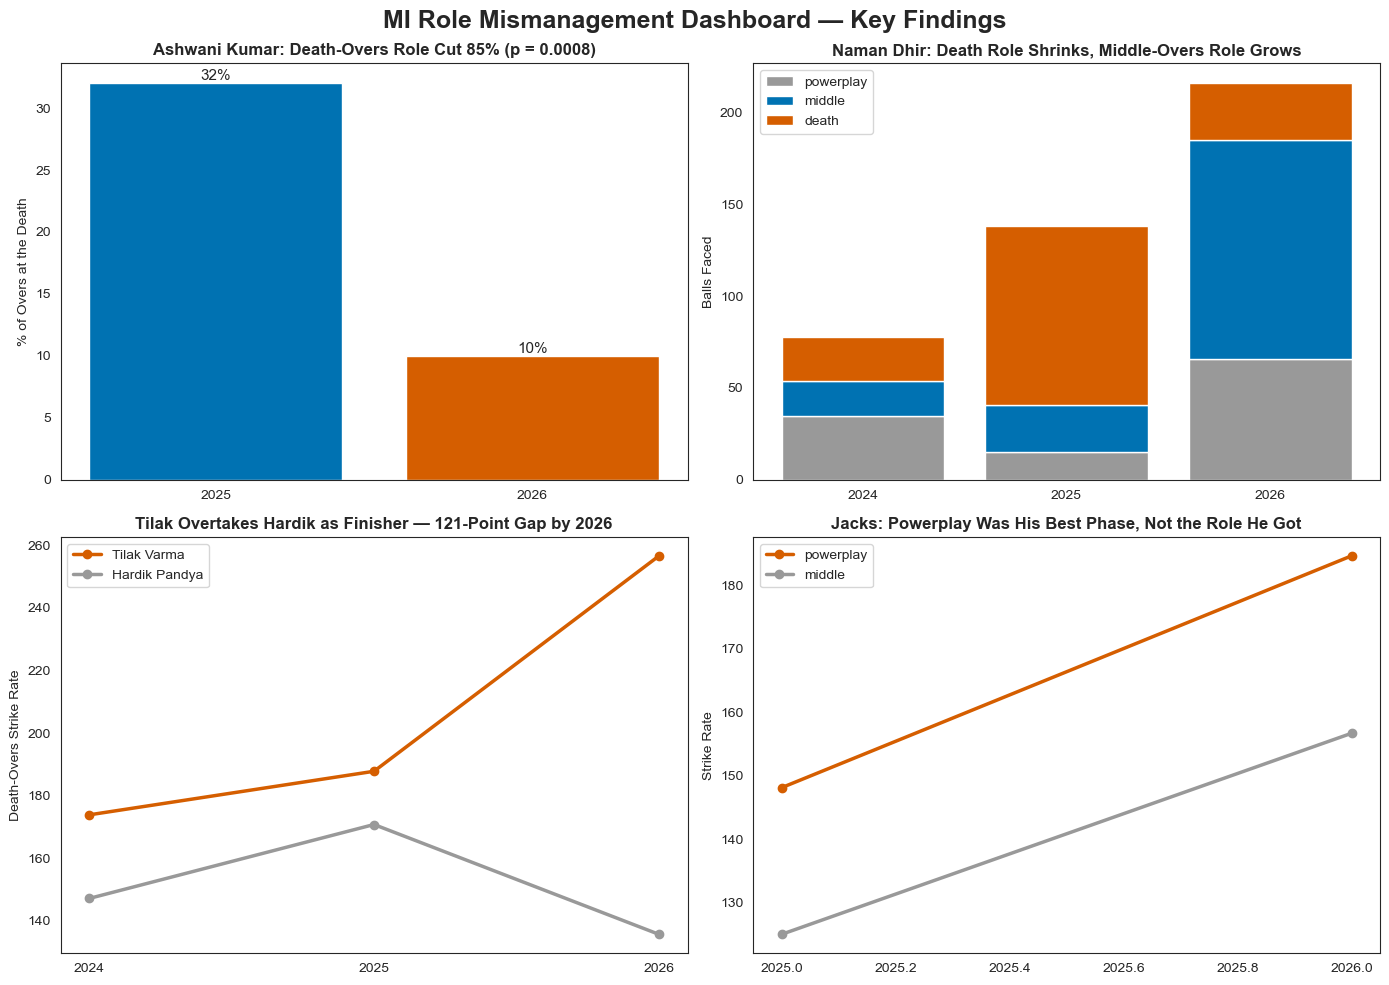

In [54]:
mi_bowling = final_data[final_data['BowlingTeam'] == 'Mumbai Indians']  # skip if already defined
mi_batting = final_data[final_data['BattingTeam'] == 'Mumbai Indians']  # skip if already defined

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MI Role Mismanagement Dashboard — Key Findings", fontsize=18, fontweight='bold')

# ── Top-left: Ashwani's death-overs share, confirmed cut ──
ax = axes[0, 0]
bars = ax.bar(['2025', '2026'], [32, 10], color=[BLUE, ACCENT])
ax.bar_label(bars, fmt='%d%%', fontsize=11)
ax.set_title("Ashwani Kumar: Death-Overs Role Cut 85% (p = 0.0008)", fontsize=12, fontweight='bold')
ax.set_ylabel("% of Overs at the Death")

# ── Top-right: Naman Dhir's role reversal, stacked bar ──
ax = axes[0, 1]
pivot = naman_numbers.pivot(index='season', columns='phase', values='balls_faced').fillna(0)
bottom = [0] * len(pivot)
for phase, color in zip(['powerplay', 'middle', 'death'], [GRAY, BLUE, ACCENT]):
    if phase in pivot.columns:
        ax.bar(pivot.index.astype(str), pivot[phase], bottom=bottom, color=color, label=phase)
        bottom = [b + v for b, v in zip(bottom, pivot[phase])]
ax.set_title("Naman Dhir: Death Role Shrinks, Middle-Overs Role Grows", fontsize=12, fontweight='bold')
ax.set_ylabel("Balls Faced"); ax.legend()

# ── Bottom-left: Tilak vs Hardik, the widening gap ──
ax = axes[1, 0]
seasons = ['2024', '2025', '2026']
tilak_vals = finisher_death[finisher_death['Batter'] == 'Tilak Varma'].sort_values('season')['strike_rate'].values
hardik_vals = finisher_death[finisher_death['Batter'] == 'HH Pandya'].sort_values('season')['strike_rate'].values
ax.plot(seasons, tilak_vals, marker='o', linewidth=2.5, color=ACCENT, label='Tilak Varma')
ax.plot(seasons, hardik_vals, marker='o', linewidth=2.5, color=GRAY, label='Hardik Pandya')
ax.set_title("Tilak Overtakes Hardik as Finisher — 121-Point Gap by 2026", fontsize=12, fontweight='bold')
ax.set_ylabel("Death-Overs Strike Rate"); ax.legend()

# ── Bottom-right: Jacks, powerplay vs middle, the role case ──
ax = axes[1, 1]
jacks_two_phase = jacks_all[jacks_all['phase'].isin(['powerplay', 'middle'])]
for phase, color in zip(['powerplay', 'middle'], [ACCENT, GRAY]):
    sub = jacks_two_phase[jacks_two_phase['phase'] == phase].sort_values('season')
    ax.plot(sub['season'], sub['strike_rate'], marker='o', linewidth=2.5, color=color, label=phase)
ax.set_title("Jacks: Powerplay Was His Best Phase, Not the Role He Got", fontsize=12, fontweight='bold')
ax.set_ylabel("Strike Rate"); ax.legend()

plt.tight_layout()
plt.savefig("../dashboard_data/role_mismanagement_dashboard_2x2.png", dpi=200, bbox_inches='tight')
plt.show()

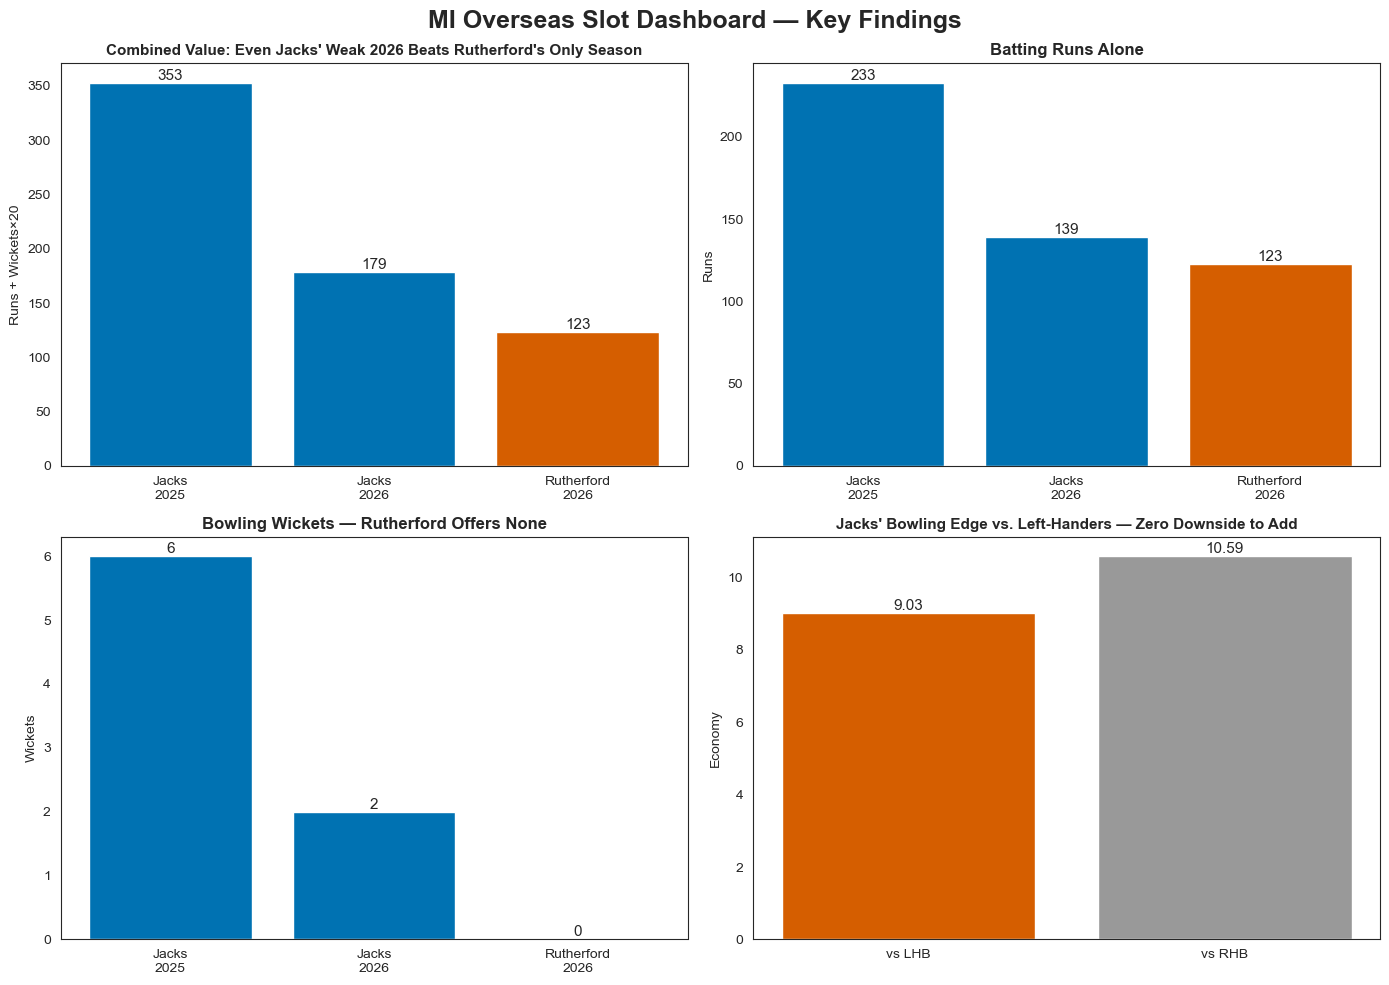

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MI Overseas Slot Dashboard — Key Findings", fontsize=18, fontweight='bold')

# ── Top-left: combined value score (runs + wickets*20) ──
ax = axes[0, 0]
players_seasons = ['Jacks\n2025', 'Jacks\n2026', 'Rutherford\n2026']
bat_runs = [233, 139, 123]
bowl_wickets = [6, 2, 0]
combined = [r + w*20 for r, w in zip(bat_runs, bowl_wickets)]
bars = ax.bar(players_seasons, combined, color=[BLUE, BLUE, ACCENT])
ax.bar_label(bars, fmt='%d', fontsize=11)
ax.set_title("Combined Value: Even Jacks' Weak 2026 Beats Rutherford's Only Season", fontsize=11, fontweight='bold')
ax.set_ylabel("Runs + Wickets×20")

# ── Top-right: batting runs only ──
ax = axes[0, 1]
bars = ax.bar(players_seasons, bat_runs, color=[BLUE, BLUE, ACCENT])
ax.bar_label(bars, fontsize=11)
ax.set_title("Batting Runs Alone", fontsize=12, fontweight='bold')
ax.set_ylabel("Runs")

# ── Bottom-left: bowling wickets ──
ax = axes[1, 0]
bars = ax.bar(players_seasons, bowl_wickets, color=[BLUE, BLUE, GRAY])
ax.bar_label(bars, fontsize=11)
ax.set_title("Bowling Wickets — Rutherford Offers None", fontsize=12, fontweight='bold')
ax.set_ylabel("Wickets")

# ── Bottom-right: Jacks LHB vs RHB economy, the deciding factor ──
ax = axes[1, 1]
bars = ax.bar(['vs LHB', 'vs RHB'], [9.03, 10.59], color=[ACCENT, GRAY])
ax.bar_label(bars, fmt='%.2f', fontsize=11)
ax.set_title("Jacks' Bowling Edge vs. Left-Handers — Zero Downside to Add", fontsize=11, fontweight='bold')
ax.set_ylabel("Economy")

plt.tight_layout()
plt.savefig("../dashboard_data/overseas_slot_dashboard_2x2.png", dpi=200, bbox_inches='tight')
plt.show()

## 21. Key Findings & Summary

**At a glance:**

| # | Finding | Headline number |
|---|---|---|
| 1 | Batting mirrors the bowling notebook's recovery-relapse arc | Death SR 173.12 → 179.33 → 165.14 |
| 2 | Surya is a middle-overs enforcer whose 2026 dip started in the powerplay | Powerplay dismissal rate hit 38.5%, his highest of 3 seasons |
| 3 | Rickelton is MI's standout 2026 batter in two phases | 214.10 middle-overs SR, a 45-point gap over 2nd place |
| 4 | Jacks' best settled phase is the powerplay | 148.10 SR on his largest single-season sample |
| 5 | Tilak's finisher role should have been obvious | 121-point 2026 gap over Hardik, corroborated at the T20 World Cup |
| 6 | Naman Dhir's productive death role was cut | 97 balls in 2025 down to 31 in 2026 |
| 7 | Hardik's decline is about survival, not tempo | Average fell from 48.70 (GT) to under 23 (MI) |
| 8 | Jacks' vs-LHB bowling is a real, low-risk bonus | 9.03 economy, 8 wickets, zero downside to MI's attack |

**Narrative summary:**

1. **MI's batting shows the same "recovery, then relapse" shape as the bowling side** — a genuine 2025 death-overs peak, followed by a 2026 fall back below even the 2024 baseline.
2. **Suryakumar Yadav remains, by volume, MI's clear middle-overs enforcer across all three seasons** (513 runs there in 2025 alone), and his 2026 numbers confirm he was still lethal whenever he got in — two of his three death-overs dismissals that season were his only 50+ scores of the year, and the third came off a strong top-order platform. His real 2026 problem is an elevated powerplay dismissal rate (38.5%, his highest of three seasons) cutting innings short before his strongest phase could even begin — not a death-overs weakness, and not a role he was ever really competing for.
3. **Ryan Rickelton is the clearest individual batting story of 2026** — a large, real jump in both the powerplay and middle overs, directly explaining the one bright spot in the team-level aggregate.
4. **Will Jacks' own two-season record supports batting him in the powerplay**, not the demoted role he was actually given — the same argument this case study opened with, now backed by data rather than opinion.
5. **The sharpest finding in this notebook is the Tilak-vs-Hardik finisher discrepancy** — a three-year, widening gap, independently corroborated by Tilak's real-world finisher role at the 2026 T20 World Cup. Surya's case, properly understood, sits apart from this thread rather than feeding into it — his gap is upstream in the innings (powerplay survival), not a competition for the finisher's role itself.
6. **Naman Dhir's case is the batting mirror of the Bowling notebook's Ashwani Kumar finding** — a productive specialist role, reassigned the following season without a performance-based reason.
7. **Hardik Pandya's decline is specifically about surviving at the crease, not scoring speed** — his GT-era average has roughly halved at MI while his strike rate has held or improved, a more precise diagnosis than a generic "he's declined" reading would offer.
8. **The Rutherford-vs-Jacks tradeoff is resolved by Jacks' bowling, not his batting alone** — a real, repeatable vs-LHB weapon that costs MI's bowling plan nothing, since the attack is already complete without him.

**Central thesis:** this notebook's findings converge with the companion Bowling Analysis notebook's own conclusion. Across bowling and batting alike, MI's 2024-2026 struggles trace less to a shortage of talent than to a **persistent failure to let data-proven roles stick** — Rickelton, Jacks, Tilak, and Naman Dhir all have seasons of strong evidence for a specific role, and in each case MI's usage either didn't follow that evidence or actively moved away from it the following year. Surya's case is a useful counterpoint: his 2026 numbers don't reflect mismanagement at all, but a genuine, earlier-in-the-innings survival dip that a phase-split analysis alone could easily have misdiagnosed as a death-overs problem — a reminder to trace a finding to its actual source before writing it up.
